# Прогнозирование движения финансовых цен

Модели прогнозирования коридора цен на золото на базе новостной ленты канала Telegram [MarketTwits](https://t.me/markettwits) и показателей технических индикаторов. В ходе работы обучается четыре модели, прогнозирующие за установленный период:
- максимальную цену;
- минимальную цену;
- рост/падение цены (относительно цены закрытия).

## Анализ требований

Итоговые модели должны выдавать прогнозируемые значения изменения цены финансового актива - границы коридора, и направление движения относительно цены закрытия за период отработки новости/финансового отчета. Данные модели планируются для использования в качестве источника сигналов рекомендательной торговой системы, а в качестве развития проекта и для автоматической торговой системы.  
Так как абсолютные значения цены актива могут лежать вне анализируемых диапазонов цен (обновление максимума/минимума), то анализу подвергается *относительная* разница между ценой закрытия и прогнозируемыми значениями. В рамках одного объекта это означает, что после получения значений всех технических индикаторов, выбранных для анализа, из тех значений, которые отражаются в масштабе цены актива (например, средние за период, Облако Ишимоку и т.п.), и прогнозируемых значений будет вычтена цена закрытия и данная разница разделена на нее. Цена закрытия выбрана в качестве опорного значения, так как она является наиболее приближенной к потенциальной цене открытия сделки в текущем моменте (в условиях низкой волатильности).  
В качестве источника текущих котировок финансового актива выступает брокер [Финам](https://www.finam.ru/), источником новостей - Telegram-канал [MarketTwits](https://t.me/markettwits).

Исходные данные для обучения модели:
- исторические данные по золоту (GOLD), доступны на странице [Актуальных архивов исторических данных (котировок)](https://daytradingschool.ru/trejderu/skachat-kotirovki-istoricheskie-dannye-po-fyuchersam/);
- новостная лента канала MarketTwits.

### Формирование аналитической задачи

На данном этапе задачу проекта сводим к решению задачи регрессии для моделей получения значений максимальной и минимальной цен и классификации для моделей определения направления движения цены.  
В качестве базовых типов моделей отдаем предпочтение классическим против моделей временных рядов, так как финансовые ряды часто нестационарны, а модели временных рядов требуют проверки на стационарность и дифференцирования, что может искажать экономическую интерпретацию, а также модели временных рядов в базовой форме слабо интегрируют внешние переменные, в то время как классические модели потенциально могут включать больше признаков.  

Так как в алгоритмах решения задачи регрессии не учитываются исторические данные, то необходима генерация признаков, обеспечивающих ретроспективность. Для этого предлагается использование значений технических индикаторов и предыдущих записей.  

При прогнозировании направления движения цены актива и моделировании принятия решения на открытие позиции действия трейдера более сходны с последовательным анализом отобранной информации, таким образом, в качестве алгоритма обучения наиболее целесообразно использование **дерева решений** и его модификаций. Для оценки качества моделей оптимально использовать среднюю абсолютную ошибку **MAE**, так как итоговое рассчетное значение MAE можно использовать в качестве одного из рассчетных параметров для формирования политики выставления страховочных заявок (stop-loss). В моделе определения направления движения цены важно сведение к минимуму ложных срабатываний и количество определяемых сигналов, соответственно для их оценки выбираем F-меру с акцентом на точность предсказаний.

Уровень значимости $\alpha$ выбираем 0.05.

### Выбор общих параметров моделей, определяемых спецификой задачи

**Продолжительность сделки**  
Разрабатываемая стратегия предполагает совершение сделок в рамках дейтрейдинга (Day Trading). Если говорить о среднем по рынку, то сделки в дейтрейдинге чаще всего занимают от 1 до 2 часов. Это оптимальное время для трейдеров, которые ищут возможности на основе внутридневных колебаний, но не хотят держать позиции слишком долго, чтобы избежать рисков ночных гэпов или изменения рыночной ситуации.  
Наиболее сильное движение рынка в рамках дня обычно укладывается в первые 30–90 минут после выхода важной новости или открытия основной торговой сессии.  
В первичной версии выбираем значение в **1 час (60 минут)**.
Данное значение будет использовано для получения целевых признаков обучающей выборки.

**Период совершения сделок**  
Торговля целевым активом (фьючерс на золото) на Московской бирже проводится в несколько сессий: 
- Аукцион открытия 08:50 - 09:00
- Утренняя сессия 09:00 - 10:00
- Основная сессия 10:00 - 14:00
- Клиринг 14:00 - 14:05
- Основная сессия 14:05 - 18:50
- Клиринг 18:50 - 19:05
- Вечерняя сессия 19:05 - 23:50

Совершение сделок целесообразно проводить в период основных торговых сессий, так как в остальные периоды низкая ликвидность может стать причиной повышенного риска и роста волатильности. Также исходя из выбранной продолжительности сделки в 1 час, ограничиваем время для отрытия позиций следующим периодом: *10:00 - 17:30*.

Так как исходные данные представляют из себя склейку торговых данных по фьючерсам, то будет необходимо на этапе очистки удалить данные в районе дней экспирации фьючерсов (2 последних дня торговли фьючерсом и 1-2 последующих дней в зависимости от величины периодов технических индикаторов для исключения участия свечей дней экспирации в вычислении их значений).

При техническом анализе японских свечей выделяемые патерны включают в себя обычно от двух до пяти свечей. Считается, что в дейтрейдинге лучше работают следующие:
- разворотные паттерны:
    - Поглощение (Bullish/Bearish Engulfing);
    - Молот и Повешенный (Hammer/Hanging Man);
    - Просвет в облаках и Завеса темных туч (Piercing Line/Dark Cloud Cover);
    - Дожи (Doji, Dragonfly Doji, Gravestone Doji);
- паттерны продолжения тренда:
    - Три белых солдата / Три черных вороны;
    - Методы трех (Rising/Falling Three Methods);
- моментумные паттерны:
    - Большая белая (черная) свеча;
    - Гэп (разрыв цены).
    
Для анализа свечных патернов наиболее оптимальны 15-минутные свечи, вышеуказанные патерны состоят максимум из трех свечей. Таким образом для учета ретроспективы к каждому объекту (минутной свече) предлагается присоединять значения цен (открытия/закрытия/максимальной/минимальной) трех предыдущих завершенных 15-минутных свечей, соответственно для генерации значений индикаторов технического анализа необходимо использовать 15-минутные свечи.

Внутридневная торговля (дейтрейдинг) не имеет прямой зависимости между днем недели и направлением сделок. Однако есть определенные особенности, которые могут влиять на торговую активность в разные дни:
- понедельник часто характеризуется повышенной волатильностью, так как трейдеры возвращаются к торгам после выходных и начинают активно открывать позиции;
- вторник-четверг обычно являются наиболее стабильными днями для внутридневной торговли, когда рынок работает в обычном режиме;
- пятница может быть менее предсказуемой из-за:
    - закрытия позиций перед выходными;
    - повышенной активности на новостях;
    - снижения ликвидности ближе к концу дня.  
    
В связи с этим имеет смысл включение дня недели в качестве одного из факторов.

### Выбор технических индикаторов
Оптимальными индикаторами для дейтрейдинга (30–90 минут) являются:
1. Скользящие средние (Moving Averages, MA)
    - EMA 9 и EMA 21 - Для краткосрочного тренда и входов.
    - SMA 50 и SMA 200  Для глобального тренда на M15/M30.  
Используются для определения направления тренда и поиска зон поддержки/сопротивления.  
Стратегия "Пересечение EMA 9 и EMA 21" дает сигналы на покупку/продажу.  
Работает хорошо на M15/M30.

2. Индикатор объема (Volume, OBV, VSA)
    - VSA (Volume Spread Analysis) помогает оценить намерения крупных игроков.
    - OBV (On Balance Volume) помогает определить направление тренда на основе объема.  
Полезен для подтверждения ложных пробоев и определения силы тренда.  
Работает на M5/M15.

3. Индекс относительной силы (RSI) Период 14 или 7
    - Выше 70 - рынок перекуплен - возможен разворот вниз.
    - Ниже 30 - рынок перепродан - возможен разворот вверх.  
Полезен для поиска входов на откатах.  
Работает на M15/M30.

4. Стохастик (Stochastic Oscillator) Период 14, 3, 3 (или 8, 3, 3 для агрессивного входа)  
Показывает зоны перекупленности и перепроданности, но лучше работает во флете.  
Хорошо работает в комбинации с RSI.  
Работает на M5/M15.

5. VWAP (Volume Weighted Average Price)  
Отображает среднюю цену с учетом объема, что помогает находить зоны поддержки/сопротивления.  
Хорошо работает для интрадейного трендового движения.  
Подходит для M5/M15.

6. Bollinger Bands (BB) Период 20  
Когда цена выходит за границы Bollinger Bands, возможен откат.  
Помогает находить моменты высокой волатильности.  
Работает на M15/M30.

7. MACD (Moving Average Convergence Divergence) Параметры: стандартные (12, 26, 9)  
Бычий сигнал: MACD пересекает сигнальную линию вверх.  
Медвежий сигнал: MACD пересекает сигнальную линию вниз.  
Подходит для фильтрации ложных сигналов.  
Работает на M15/M30.

Классическими комбинациями индикаторов для дейтрейдинга (30–90 минут) приняты:  
1. Трендовая стратегия
- EMA 9 и EMA 21 – для подтверждения тренда.
- VWAP – для определения зон входа.
- RSI – для оценки силы тренда.
- MACD – для подтверждения входа.
- Рабочие таймфреймы: M15/M30.
2. Контртрендовая стратегия (развороты)
- Bollinger Bands – для нахождения экстремумов.
- RSI + Стохастик – для поиска точек разворота.
- VSA – для оценки объема на экстремумах.
- Рабочие таймфреймы: M5/M15.
3. Пробойная стратегия
- SMA 50 + SMA 200 – определяют глобальный тренд.
- VWAP + Volume – подтверждают силу пробоя.
- RSI – подтверждает импульс.
- Рабочие таймфреймы: M15/M30.

На данной итерации выбираем технические индикаторы трендовой стратегии:
- EMA, период 9;
- EMA, период 21;
- VWAP, с начала торговой сессии;
- RSI, период 7.
- MACD, параметры (12, 26, 9).

In [1]:
# Глобальные параметры
alpha = 0.05 # параметр альфа
main_period = '15min' # период сжатия минутного графика свечей и рассчета технических индикаторов
main_period_int = 15
# Параметры технических индикаторов
period_EMA_fast = 9
period_EMA_slow = 21
period_RSI = 7
period_MACD_fast = 12
period_MACD_slow = 26
period_MACD_signal = 9
# Количество вычисляемых уровней расширения Фибоначчи
count_FE_levels = 7
# Значение для вычисления ближайших "круглых чисел"
round_price = 5
# Шаг цены инстумента
step_price = 0.1
# Период соранения позиции в минутах
period_holding_position = 60
# Количество свечей, обеспечивающих ретроспективность котировок
count_previous_candle = 3
# Количество свечей, обеспечивающих ретроспективность сообщений
count_previous_messages = 2
# Количество знаков для округления значений технических индикаторов, 
# вычисляемых в масштабе, отличном от цены актива
round_ta = 2
# Порог для определения направления движения цены в процентах
level_price_movement_direction = 0.1

# Необходимость пересчета моделей
recalculating_model_to_up = True
recalculating_model_to_down = True
recalculating_model_high = True
recalculating_model_low = True
# Поредел значения корреляции признаков для удаления
corr_limit = 0.8
# Фиксируем random_state
rs = 42

## Загрузка и обзор данных

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import mplfinance as fplt
import pandas_ta_classic as ta
import category_encoders as ce
import scipy.stats as stats
from plotly.subplots import make_subplots

# Получение тональности финансовых текстов
import math
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm

# Обучение модели  
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBClassifier, XGBRegressor
from sklearn import metrics # инструменты для оценки точности модели

# Подбор гиперпараметров моделей
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# Сериализация/десериализация
import joblib

In [3]:
def plot_numerical_feature(data: pd.DataFrame, col: str, main_title: str):
    ''' Функция отрисовывает коробчатую диаграмму и гистограмму распределения
    и выводит статистические данные числового признака.
    Args:
        data (pd.DataFrame): датасет
        col (str): наименование признака
        main_title (str): расшифровка наименования признака для вывода
            в титуле графика
    Returns:
        None
    '''
    # Инициализация полотна на два графика с общей осью X
    fig_col = make_subplots(rows=2, cols=1,
                            shared_xaxes=True, # Общая ось Х
                            x_title=main_title,
                            y_title='Количество',
                            row_heights=[0.15, 0.85], # Относительная высота полотен
                            subplot_titles=(f"Распределение признака <br>\"{main_title}\"", ""),
                            vertical_spacing=0.02) # Высота разделителя
    # Построение коробчатой диаграммы
    fig_col.add_trace(go.Box(x=data[col],
                             marker_color = '#1729B0', # Цвет маркера
                             jitter=0.5, # Разнос точек выбросов по вертикали
                             name='',
                             showlegend=False),
                      row=1, col=1)
    # Построение гистограммы
    fig_col.add_trace(go.Histogram(x=data[col],
                                   marker_color = '#1729B0', # Цвет маркера
                                   name=main_title, # Название набора данных
                                   showlegend=False),
                      row=2, col=1)
    # Построение линии среднего значения
    fig_col.add_vline(x=data[col].mean(),
                      line=dict(color="Red", dash='dash')) # Стиль линии
    # Размер полотна
    fig_col.update_layout(autosize = True, bargap=0.1) # Расстояние между столбцами гистограммы
    fig_col.show('png')
    # fig_col.show()

    print('Статистические данные признака:')
    display(data[col].describe().round(2))

In [4]:
def plot_categorical_feature(data: pd.DataFrame, col: str, main_title: str):
    ''' Функция отрисовывает бары распределения и выводит статистические
    данные категориального признака. Количество баров ограничено 70, 
    длина подписи значений оси - 15 символов.
    Args:
        data (pd.DataFrame): датасет
        col (str): наименование признака
        main_title (str): расшифровка наименования признака для вывода
            в титуле графика
    Returns:
        None
    '''
    # Подготовка данных
    count_bar = 70
    len_xtext = 15
    df_tmp = data[col].value_counts().reset_index()
    df_tmp[col] = df_tmp[col].apply(lambda x: x[:len_xtext]+'...' if len(str(x)) > len_xtext else x)
    # Инициализация полотна
    fig_col = go.Figure(data=go.Bar(x=df_tmp[col].head(count_bar).index,
                                    y=df_tmp['count'].head(count_bar)))
    
    # Размер полотна
    fig_col.update_layout(autosize = True)
    # Заголовок диаграммы
    fig_col.update_layout(title=f"Распределение признака <br>\"{main_title}\"",
                          title_x=0.5, # Расположение посередине
                          xaxis_title=main_title, # Подпись Х
                          yaxis_title='Количество', # Подпись Y
                          xaxis=dict(tickvals=df_tmp[col].head(count_bar).index, # Оригинальные значения для оси X
                                     ticktext=df_tmp[col].head(count_bar))) # Новые подписи для оси X                   
    fig_col.show('png')
    # fig_col.show()
    
    print('Статистические данные признака:')
    display(data[col].describe())
    print('Top-10 значений (%):')
    display(data[col].value_counts(normalize=True).head(10).round(4)*100)

In [5]:
! pip freeze > requirements.txt

### Загрузка котировок финансового актива

In [6]:
df_init = pd.read_csv('./data/GOLD.txt')
df_init.info()
df_init.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3010469 entries, 0 to 3010468
Data columns (total 9 columns):
 #   Column    Dtype  
---  ------    -----  
 0   <TICKER>  object 
 1   <PER>     int64  
 2   <DATE>    int64  
 3   <TIME>    int64  
 4   <OPEN>    float64
 5   <HIGH>    float64
 6   <LOW>     float64
 7   <CLOSE>   float64
 8   <VOL>     int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 206.7+ MB


,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
3010464,GOLD,1,20260731,234500,4071.8,4071.9,4070.5,4071.6,70
3010465,GOLD,1,20260731,234600,4070.8,4071.2,4070.7,4071.2,9
3010466,GOLD,1,20260731,234700,4071.2,4071.2,4071.0,4071.2,46
3010467,GOLD,1,20260731,234800,4071.0,4071.0,4070.1,4070.1,45
3010468,GOLD,1,20260731,234900,4070.9,4072.7,4070.0,4070.7,215


In [7]:
# Удаление неинформативных столбцов
df_init.drop(['<TICKER>', '<PER>'], axis=1, inplace=True)
# Переименование столбцов
df_init.rename(columns={'<OPEN>': 'open',
                        '<HIGH>': 'high',
                        '<LOW>': 'low',
                        '<CLOSE>': 'close',
                        '<VOL>': 'volume'},
               inplace=True)
# Преобразование времени свечей
df_init['dt'] = df_init['<DATE>'].astype(str) + ' ' + df_init['<TIME>'].astype(str)
df_init['dt'] = pd.to_datetime(df_init['dt'], format="%Y%m%d %H%M%S")
# Добавление дня недели
df_init['day_of_week'] = df_init['dt'].dt.day_name()
df_init = df_init[['dt', 'open', 'high', 'low', 'close', 'volume', 'day_of_week']]

df_M1 = df_init.copy()
df_M1.set_index('dt', inplace=True)

df_M1.info()
df_M1.tail()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3010469 entries, 2009-01-11 10:33:00 to 2026-07-31 23:49:00
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   open         float64
 1   high         float64
 2   low          float64
 3   close        float64
 4   volume       int64  
 5   day_of_week  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 160.8+ MB


,open,high,low,close,volume,day_of_week
dt,,,,,,
2026-07-31 23:45:00,4071.8,4071.9,4070.5,4071.6,70,Friday
2026-07-31 23:46:00,4070.8,4071.2,4070.7,4071.2,9,Friday
2026-07-31 23:47:00,4071.2,4071.2,4071.0,4071.2,46,Friday
2026-07-31 23:48:00,4071.0,4071.0,4070.1,4070.1,45,Friday
2026-07-31 23:49:00,4070.9,4072.7,4070.0,4070.7,215,Friday


Датасет котировок на золото **df_M1** содержит значения минутных свечей и объема торгов начиная с 11 января 2009 года по 31 июля 2026 года, 3010469 строк.

Для обучения моделей выбираем период с 1 августа 2022 года по 31 июля 2026. Данный период необходим для поддержания баланса, так как если взять слишком много старых данных, модели могут зафиксировать устаревшие паттерны, а если выбрать только последний небольшой период, то существует риск переобучения на шуме. В условиях задачи решено опираться на 4 года данных. Так современная конъюнктура будет весомее, но при этом в выборке сохранится достаточная вариативность рыночных условий.

In [8]:
# Фильтрация записей за период
mask = (df_M1.index > '2022-08-01 00:00:00') & \
       (df_M1.index < '2026-08-01 00:00:00')
df_M1 = df_M1[mask]
df_M1.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 895517 entries, 2022-08-01 10:00:00 to 2026-07-31 23:49:00
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   open         895517 non-null  float64
 1   high         895517 non-null  float64
 2   low          895517 non-null  float64
 3   close        895517 non-null  float64
 4   volume       895517 non-null  int64  
 5   day_of_week  895517 non-null  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 47.8+ MB


Датасет минутных свечей после отбора за период содержит 895517 записей.

Свернем полученный датасет до 15-минутного таймфрейма свечей.

In [9]:
# Сворачивание данных в 15-минутные свечи
df_main_period = df_M1.resample(main_period).agg({'open': 'first',   # Первая цена открытия за 15 минут
                                                  'high': 'max',     # Максимальная цена за 15 минут
                                                  'low': 'min',      # Минимальная цена за 15 минут
                                                  'close': 'last',   # Последняя цена закрытия за 15 минут
                                                  'volume': 'sum'})  # Сумма объема за 15 минут
df_main_period.dropna(axis=0, inplace=True)
print(df_main_period)

                       open    high     low   close  volume
dt                                                         
2022-08-01 10:00:00  1770.4  1777.0  1768.4  1774.6    4640
2022-08-01 10:15:00  1774.5  1775.9  1770.3  1771.6    2441
2022-08-01 10:30:00  1771.6  1771.8  1762.6  1767.3    5383
2022-08-01 10:45:00  1767.3  1769.7  1766.5  1769.5     616
2022-08-01 11:00:00  1769.2  1769.5  1765.6  1766.6    1441
...                     ...     ...     ...     ...     ...
2026-07-31 22:45:00  4074.7  4076.0  4072.0  4073.0    1394
2026-07-31 23:00:00  4073.0  4073.0  4067.1  4067.8    1218
2026-07-31 23:15:00  4067.9  4068.7  4066.6  4067.6     673
2026-07-31 23:30:00  4067.6  4073.0  4067.2  4071.8    1006
2026-07-31 23:45:00  4071.8  4072.7  4070.0  4070.7     385

[63539 rows x 5 columns]


Датасет котировок на золото **df_main_period** содержит значения 15-минутных свечей и объема торгов за ранее выбранный период и включает 63539 строк.

### Загрузка и обзор сообщений новостного канала

Произведем загрузку датасета, полученного при выполнении файла MsgDownload.ipynb.

In [10]:
df_msgs = pd.read_csv('./data/tg_messages.csv')
df_msgs.info()
df_msgs.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171856 entries, 0 to 171855
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   date_utc  171856 non-null  object
 1   message   171856 non-null  object
dtypes: object(2)
memory usage: 2.6+ MB


,date_utc,message
0,2026-07-31T21:01:39+00:00,❗️⚠️🇮🇷#иран #геополитика \nСША И ИЗРАИЛЬ ГОТОВ...
1,2026-07-31T19:06:20+00:00,"🇮🇷#иран #today #трамп \nТрамп заявил, что Уитк..."
2,2026-07-31T18:25:15+00:00,🚫✴️🇷🇺#майнинг #россия #крипто\nПравительство Р...
3,2026-07-31T18:22:45+00:00,"🇺🇸🇷🇺#санкции #россия \nЗаконопроект об ""адских..."
4,2026-07-31T18:04:08+00:00,❗️🇯🇵 #fx #япония #интервенции\nСША и Япония пр...


Приведем столбец date_utc ко времени с учетом часового пояса и проведем контрольный отбор за период. Также "развернем" датасет по возрастанию времени.

In [11]:
df_msgs['dt'] = pd.to_datetime(df_msgs['date_utc'], format='ISO8601').dt.tz_convert('Europe/Moscow')
df_msgs['dt'] = df_msgs['dt'].dt.tz_localize(None)
df_msgs.drop(columns=['date_utc'], inplace=True)
df_msgs.set_index('dt', inplace=True)
# Фильтрация записей за период
mask = (df_msgs.index > '2022-08-01 00:00:00') & \
       (df_msgs.index < '2026-08-01 00:00:00')
df_msgs = df_msgs[mask]
df_msgs.sort_index(ascending=True, inplace=True)
df_msgs.info()
df_msgs.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 171855 entries, 2022-08-01 07:19:42 to 2026-07-31 22:06:20
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   message  171855 non-null  object
dtypes: object(1)
memory usage: 2.6+ MB


,message
dt,
2022-08-01 07:19:42,🗓КАЛЕНДАРЬ НА СЕГОДНЯ - 2022.08.01\n\n📌ТОРГИ\n...
2022-08-01 07:22:52,🌎#рынки
2022-08-01 07:23:28,🌎#FX
2022-08-01 07:25:18,🌎#ты
2022-08-01 07:33:34,⚠️🇷🇸#сербия #косово #геополитика #нато \nМисси...


Датасет сообщений новостного канала содержит 171855 сообщений в поле message за период с 07:19 1 августа 2022 года по 22:06 31 июля 2026 года. Сообщения представлены в текстовом виде и не могут быть переданы для обучения в текущем виде, требуется проведение их обработки и кодирования.

## Предварительная подготовка данных

### Сообщения новостного канала

Сообщения новостного канала требуют обработки и выделения отдельных признаков.  
Часть сообщений содержат хештеги, выделим их в отдельный признак tags, текст сообщения без тегов поместим в признак text.

In [12]:
reg = r'#\w+'
df_msgs['tags'] = df_msgs['message'].str.findall(reg)
df_msgs['text'] = df_msgs['message'].str.replace(r'#\w+', '', regex=True)
df_msgs.head()

,message,tags,text
dt,,,
2022-08-01 07:19:42,🗓КАЛЕНДАРЬ НА СЕГОДНЯ - 2022.08.01\n\n📌ТОРГИ\n...,"[#MDMG, #ON, #PINS, #ZI, #ATVI, #MOS]",🗓КАЛЕНДАРЬ НА СЕГОДНЯ - 2022.08.01\n\n📌ТОРГИ\n...
2022-08-01 07:22:52,🌎#рынки,[#рынки],🌎
2022-08-01 07:23:28,🌎#FX,[#FX],🌎
2022-08-01 07:25:18,🌎#ты,[#ты],🌎
2022-08-01 07:33:34,⚠️🇷🇸#сербия #косово #геополитика #нато \nМисси...,"[#сербия, #косово, #геополитика, #нато]",⚠️🇷🇸 \nМиссия НАТО KFOR заявила о готовност...


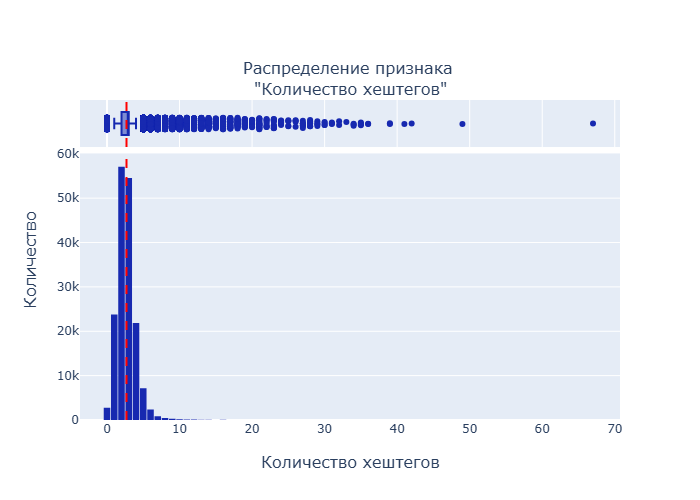

Статистические данные признака:


count    171855.00
mean          2.69
std           1.51
min           0.00
25%           2.00
50%           3.00
75%           3.00
max          67.00
Name: count_tags, dtype: float64

In [13]:
df_msgs['count_tags'] = df_msgs['tags'].apply(lambda x: len(x))

# Построение распределения количества тегов
plot_numerical_feature(df_msgs, 'count_tags', 'Количество хештегов')

Количество тегов в сообщениях канала распределено от 0 до 67, при этом, исходя из графика, сообщения, в которых количество хештегов более 4, очистим как выбросы.
Также, исходя из наблюдений за публикациями канала, нетегированные сообщения не несут в себе существенной информации, они в основном рекламные или освещают незначительные события, соответственно также подлежат удалению.

In [14]:
mask = (df_msgs['count_tags'] > 0) & (df_msgs['count_tags'] <= 4)
df_msgs = df_msgs[mask]
len(df_msgs)

157235

После очистки осталось 157235 сообщений.  
Проверим наличие сообщений, состоящих только из тегов, это могут быть сообщения, в которых информация приведена в прикрепленных мультимедиа (не обрабатываемая по условиям задачи).

In [15]:
df_msgs['text'] = df_msgs['text'].str.replace(r'[^a-zA-Z0-9а-яА-ЯёЁ]', '', regex=True)
len(df_msgs[df_msgs['text'] == ''])

3752

Таких сообщений 3752, очистим и от них, также удалим временный столбец text.

In [16]:
mask = df_msgs['text'] != ''
df_msgs = df_msgs[mask]
df_msgs.drop(columns=['text'], inplace=True)

В канале присутствуют "напоминающие" сообщения, включающие символы "❗️ВПЕРЕДИ", они не несут в себе информации, влияющей на цену актива, поэтому подлежат удалению.

In [17]:
mask = df_msgs['message'].str.contains('❗️ВПЕРЕДИ', na=False)
index_del = df_msgs[mask].index
df_msgs.drop(index=index_del, inplace=True)
df_msgs.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 153452 entries, 2022-08-01 07:33:34 to 2026-07-31 22:06:20
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   message     153452 non-null  object
 1   tags        153452 non-null  object
 2   count_tags  153452 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.7+ MB


Таким образом, после предварительной очистки осталось 153452 сообщения.  

Произведем оценку частоты использования хештегов.

In [18]:
all_tags = df_msgs['tags'].explode().unique().tolist()
len(all_tags)

4763

Всего в датасете встречается 4763 различных тега. Часть из них потенциально могут быть выделены в качестве отдельных признаков, остальные могут быть использованы как признак "в совокупности".

In [19]:
# Формирование статистики использования хештегов
dict_tags = {}
for tag in all_tags:
    dict_tags[tag] = df_msgs['tags'].apply(lambda x: tag in x).sum()
# Сортировка значений
dict_tags = dict(sorted(dict_tags.items(), key=lambda item: item[1], reverse=True))

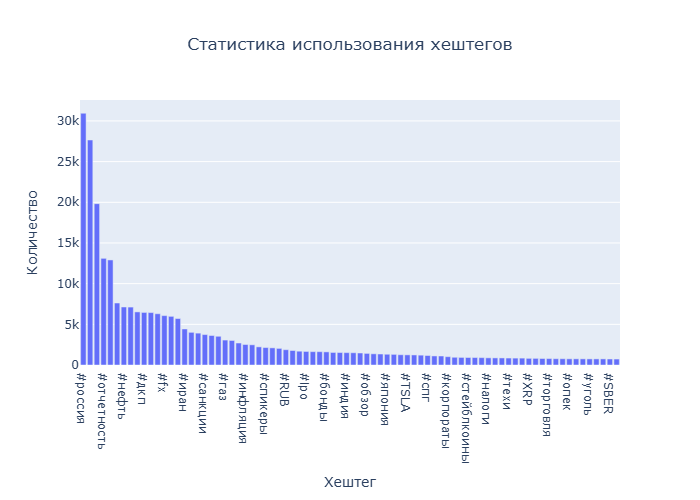

In [20]:
# Построение графика
count_bar = 80                                                                      
# Инициализация полотна
fig_col = go.Figure(data=go.Bar(x=list(dict_tags.keys())[:count_bar],
                                y=list(dict_tags.values())[:count_bar]))
# Размер полотна
fig_col.update_layout(autosize = True)
# Заголовок диаграммы
fig_col.update_layout(title=f"Статистика использования хештегов",
                        title_x=0.5, # Расположение посередине
                        xaxis_title='Хештег', # Подпись Х
                        yaxis_title='Количество') # Подпись Y
fig_col.show('png')
# fig_col.show()

Исходя из частоты использования хештегов и отмечаемых особенностей финансового актива (золота), в качестве отдельных признаков выделяем:
- геополитика;
- отчетность;
- прогноз;
- экономика;
- дкп;
- инфляция;
- отчетности;
- золото.

К ним же добавим теги наиболее популярных стран/регионов:
- Россия;
- США;
- Китай;
- Европа;
- Украина;
- Иран;
- Британия;
- Япония;
- Индия;
- Германия.

Списки тегов оставляем в качестве отдельного признака. Так как при сравнении списков на равенство важен порядок элементов, то после выделения тегов сообщения в списки будет проводиться их сортировка.

In [21]:
col_tags = ['#геополитика', '#отчетность', '#прогноз', '#экономика',
            '#дкп', '#инфляция', '#отчетности', '#золото',
            '#россия', '#сша', '#китай', '#европа', '#украина', 
            '#иран', '#британия', '#япония', '#индия', '#германия']
# Формирование признаков наличия тега из списка в сообщении
for ct in col_tags:
    df_msgs[ct] = df_msgs['tags'].apply(lambda x: ct in x)
# Сортировка списков тегов
df_msgs['tags'] = df_msgs['tags'].apply(lambda x: sorted(x))

In [22]:
df_msgs['tags_comb'] = df_msgs['tags'].apply(lambda x: ''.join(x))
df_msgs['tags_comb'].nunique()

32875

In [23]:
# Формирование статистики использования сочетаний хештегов
dict_tags_comb = {}
for tag in df_msgs['tags_comb'].unique():
    dict_tags_comb[tag] = df_msgs['tags_comb'].apply(lambda x: tag in x).sum()
# Сортировка значений
dict_tags_comb = dict(sorted(dict_tags_comb.items(), key=lambda item: item[1], reverse=True))

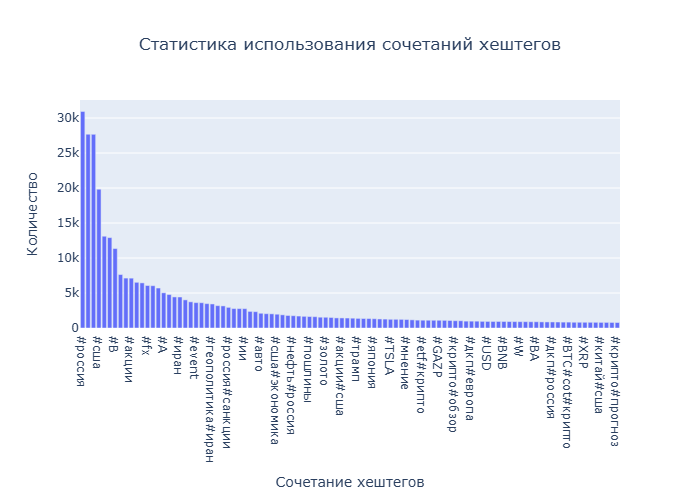

In [24]:
# Построение графика
count_bar = 100                                                                      
# Инициализация полотна
fig_col = go.Figure(data=go.Bar(x=list(dict_tags_comb.keys())[:count_bar],
                                y=list(dict_tags_comb.values())[:count_bar]))
# Размер полотна
fig_col.update_layout(autosize = True)
# Заголовок диаграммы
fig_col.update_layout(title=f"Статистика использования сочетаний хештегов",
                      title_x=0.5, # Расположение посередине
                      xaxis_title='Сочетание хештегов', # Подпись Х
                      yaxis_title='Количество') # Подпись Y
fig_col.show('png')
# fig_col.show()

В датасете присутствует 32875 сочетаний хештегов. В качестве признаков оставим те сочетания, которые встречаются в 95% сообщений, остальные пометим как "другие", в эту же категорию будут попадать сочетания хештегов новых сообщений, в режиме работы на реальных данных. Данный признак планируется кодировать посредством Binary Encoding, поэтому даже при максимальном количестве сочетаний добавится всего 16 признаков, что приемлемо в условиях задачи.

In [25]:
def get_top_cat(freq_dict, share=0.99):
    # Сортирровка по убыванию частоты
    sorted_items = sorted(freq_dict.items(), key=lambda x: x[1], reverse=True)
    
    total = sum(freq_dict.values())
    cumulative = 0
    result_tags = []
    
    for tag, count in sorted_items:
        cumulative += count
        result_tags.append(tag)
        if cumulative / total >= share:
            break
    
    return result_tags

In [26]:
# Получение списка сочетаний тегов, обеспечивающего покрытие 95% сообщений
top_tags_comb = get_top_cat(dict_tags_comb, 0.95)
len(top_tags_comb)

8663

В 95% сообщений встречается 8663 сочетания хештегов + 1 категория для "остальных", что при Binary Encoding создаст дополнительно 14 признаков.

В качестве признака текст сообщения в чистом виде не может быть использован, для получения тональности сообщения использование стандартных библиотек не рекомендуется, так как в финансовых текстах возможны ошибки, потому что происходит оценка слов изолированно, без учета контекста. Из существующих анализаторов финансовых текстов наиболее приемлемый вариант использовать модель FinBERT библиотеки Hugging Face Transformers ввиду ее доступности и относительно малых вычислительных требований.

In [27]:
# Получение тональности сообщений
# Настройка устройства
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используемое устройство: {device}")
if device == "cuda":
    print(f"Видеокарта: {torch.cuda.get_device_name(0)}")
    print(f"CUDA версия (runtime): {torch.version.cuda}")
else:
    print("!!!GPU не найден. Работа будет идти на CPU (медленнее).")
# Загрузка модели и токенизатора
model_name = "ProsusAI/finbert"
print("Загрузка модели FinBERT...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                           use_safetensors=True)
# Перенс модели на устройство
model.to(device)
model.eval()  # Режим оценки (отключает dropout и т.д.)
# Категории тональности сообщений
labels = ["negative", "neutral", "positive"]

# Подготовка данных
texts = df_msgs['message'].tolist()
# Сохранение индексов
original_indices = df_msgs['message'].index.tolist()

print(f"Сообщений для анализа: {len(texts)}")
# Пакетная обработка (BATCHING) с GPU
batch_size = 128  # Варианты для GPU: 16, 32, 64, 128. Если Out Of Memory - уменьшать значение.
n_batches = math.ceil(len(df_msgs) / batch_size)

all_probs = []

print("Запуск инференса на GPU...")

for i in tqdm(range(n_batches), desc="FinBERT Inference"):
    batch_texts = texts[i*batch_size:(i+1)*batch_size]
    # Токенизация
    inputs = tokenizer(batch_texts,
                       return_tensors="pt",
                       truncation=True,
                       padding=True,
                       max_length=512)
    # Перенос тензоров на GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model(**inputs).logits
    # Получение вероятности
    probs = F.softmax(logits, dim=-1)
    all_probs.append(probs)
    
# Объединение батчей в один тензор и перенос на CPU для работы с pandas
all_probs_tensor = torch.cat(all_probs, dim=0)
all_probs_np = all_probs_tensor.cpu().numpy()

# Формирование результатов
pred_ids = np.argmax(all_probs_np, axis=1)
pred_labels = [labels[i] for i in pred_ids]
pred_conf = all_probs_np[np.arange(len(pred_ids)), pred_ids]

# Создание DataFrame с результатами
df_sent = pd.DataFrame({"prob_neg": all_probs_np[:, 0],
                        "prob_neu": all_probs_np[:, 1],
                        "prob_pos": all_probs_np[:, 2],
                        "sentiment": pred_labels,
                        "confidence": pred_conf})
# Восстановление исходных индексов
df_sent.index = original_indices
# Слияние с исходным датасетом
df_msgs_full = pd.concat([df_msgs, df_sent], axis=1)

Используемое устройство: cuda
Видеокарта: NVIDIA GeForce RTX 4070 Laptop GPU
CUDA версия (runtime): 12.1
Загрузка модели FinBERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Сообщений для анализа: 153452
Запуск инференса на GPU...


FinBERT Inference: 100%|██████████| 1199/1199 [33:19<00:00,  1.67s/it]


In [28]:
df_msgs_full.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 153452 entries, 2022-08-01 07:33:34 to 2026-07-31 22:06:20
Data columns (total 27 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   message       153452 non-null  object 
 1   tags          153452 non-null  object 
 2   count_tags    153452 non-null  int64  
 3   #геополитика  153452 non-null  bool   
 4   #отчетность   153452 non-null  bool   
 5   #прогноз      153452 non-null  bool   
 6   #экономика    153452 non-null  bool   
 7   #дкп          153452 non-null  bool   
 8   #инфляция     153452 non-null  bool   
 9   #отчетности   153452 non-null  bool   
 10  #золото       153452 non-null  bool   
 11  #россия       153452 non-null  bool   
 12  #сша          153452 non-null  bool   
 13  #китай        153452 non-null  bool   
 14  #европа       153452 non-null  bool   
 15  #украина      153452 non-null  bool   
 16  #иран         153452 non-null  bool   
 17  #британия     

In [29]:
# Краткая статистика
print("\nСтатистика тональности:")
print(df_msgs_full["sentiment"].value_counts())
print(f"Средняя уверенность модели: {df_msgs_full['confidence'].mean():.3f}")


Статистика тональности:
sentiment
positive    150975
negative      1603
neutral        874
Name: count, dtype: int64
Средняя уверенность модели: 0.835


В результате обработки текста сообщений моделью FinBERT получены следующие признаки:
- prob_neg, prob_neu, prob_pos - вероятности текста быть финансово негативной, нейтральной или позитивной новостью;
- sentiment - класс новости (с наибольшей вероятностью);
- confidence - вероятность класса новости.

Признаки sentiment и confidence для модели избыточны и фактически вытекают из prob_neg, prob_neu и prob_pos, а, соответственно, подлежат удалению.  
Из признаков prob_neg, prob_neu и prob_pos можно получить сверточный признак sent_score, равный разнице вероятностей позитивной и негативной тональности, таким образом мы получим тональность одним числом от -1 до 1, где -1 это абсолютно негативный тон, 0 - нейтральный, а 1 - абсолютно позитивный.  
Для выбранных алгоритмов машинного обучения оставим и три вероятности, и sent_score, данная избыточность невелика, но может дать лучший вариант при обучении.

Также сразу удалим признаки:
- message - обработан, получены новые признаки;
- tags - обработан, получены новые признаки;
- count_tags - не имеет информационного значения для целевых признаков.

In [30]:
df_msgs_full.drop(columns=['sentiment','confidence', 'message', 'tags', 'count_tags'],
                  inplace=True)
df_msgs_full['sent_score'] = df_msgs_full['prob_pos'] - df_msgs_full['prob_neg']

Проведем кодирование признака tags_comb с использованием полученного списка сочетаний тегов посредством бинарного кодирования.

In [31]:
# Изменение значения сочетаний тегов на "other" для невошедших в список
df_msgs_full['tags_comb'] = df_msgs_full['tags_comb'].apply(lambda x: 'other' if x not in top_tags_comb else x)
# Бинарное кодирование признака
encoder_tags_comb = ce.BinaryEncoder(cols=['tags_comb'])
encoded_tc = encoder_tags_comb.fit_transform(df_msgs_full[['tags_comb']])
print(f'Закодировано в {encoded_tc.shape[1]} признаках')
df_msgs_full = pd.concat([df_msgs_full, encoded_tc], axis=1)
# Удаление признака tags_comb
df_msgs_full.drop(columns=['tags_comb'], inplace=True)

Закодировано в 14 признаках


In [32]:
df_msgs_full.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 153452 entries, 2022-08-01 07:33:34 to 2026-07-31 22:06:20
Data columns (total 36 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   #геополитика  153452 non-null  bool   
 1   #отчетность   153452 non-null  bool   
 2   #прогноз      153452 non-null  bool   
 3   #экономика    153452 non-null  bool   
 4   #дкп          153452 non-null  bool   
 5   #инфляция     153452 non-null  bool   
 6   #отчетности   153452 non-null  bool   
 7   #золото       153452 non-null  bool   
 8   #россия       153452 non-null  bool   
 9   #сша          153452 non-null  bool   
 10  #китай        153452 non-null  bool   
 11  #европа       153452 non-null  bool   
 12  #украина      153452 non-null  bool   
 13  #иран         153452 non-null  bool   
 14  #британия     153452 non-null  bool   
 15  #япония       153452 non-null  bool   
 16  #индия        153452 non-null  bool   
 17  #германия     

Таким образом, в ходе обработки сообщений новостного канала получен датасет, включающий в себя 153452 записи по 36 признакам. Данные обработаны и закодированы и могут быть использованы для обучения ML-моделей без дополнительной обработки.

### Вычисление факторов на базе котировок

Далее проведем вычисление признаков цен финансового актива на базе принятых в работу по условиям задачи индикаторов.

Вычисление значений индикаторов на 15-минутном графике.

In [33]:
# EMA, период 9
df_main_period['EMA_fast'] = ta.ema(df_main_period['close'], length=period_EMA_fast)
# EMA, период 21
df_main_period['EMA_slow'] = ta.ema(df_main_period['close'], length=period_EMA_slow)
# VWAP, с начала торговой сессии
df_main_period['VWAP'] = ta.vwap(df_main_period['high'], df_main_period['low'], df_main_period['close'], df_main_period['volume'])
# RSI, период 7
df_main_period['RSI'] = ta.rsi(df_main_period['close'], length=period_RSI)
# MACD, параметры (12, 26, 9)
MACD = ta.macd(df_main_period['close'], fast=period_MACD_fast, slow=period_MACD_slow, signal=period_MACD_signal)
added_name = '_' + str(period_MACD_fast) + '_' + str(period_MACD_slow) + '_' + str(period_MACD_signal)
df_main_period['MACD'] = MACD['MACD' + added_name]
df_main_period['MACD_signal'] = MACD['MACDs' + added_name]
df_main_period['MACD_hist'] = MACD['MACDh' + added_name]

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


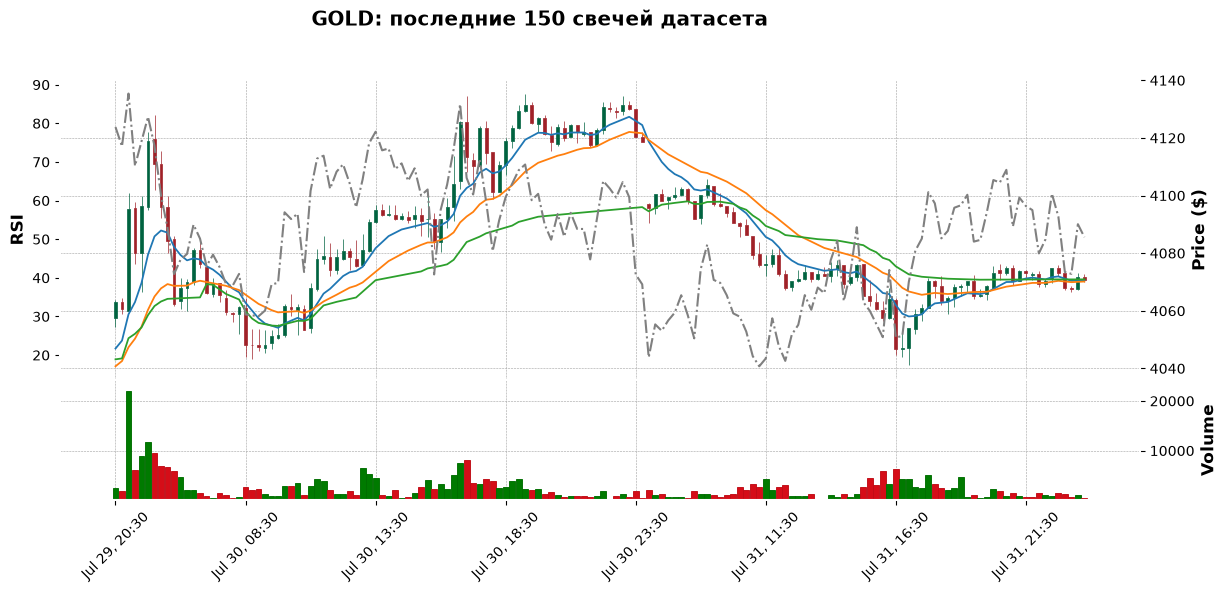

In [34]:
# Отбор данных
show_df = df_main_period.tail(150)
# Построение графика японских свечей с индикаторами
ema = fplt.make_addplot(show_df[['EMA_fast', 'EMA_slow', 'VWAP']])
rsi = fplt.make_addplot(show_df["RSI"], color="grey", width=1.5, ylabel="RSI",
                        secondary_y=True, linestyle='dashdot')
fplt.plot(show_df,
          type='candle',
          addplot=[ema, rsi],
          volume=True,
          style='charles',
          title='GOLD: последние 150 свечей датасета',
          ylabel='Price ($)',
          figsize=(15, 6))
fplt.show()

Приведенный выше график показывает, что, несмотря на видимую взаимосвязь движения цены актива и отраженных индикатов, присутствует достаточно сильная корректирующая составляющая, не позволяющая определить целевые показатели торлько на базе цены и числовых индикаторов, но их наличие способно уменьшить общую неопределенность.  
В этой части сформируем признаки для обучения ML-моделей, основываясь на ценовом движении актива.

Согласно книги Стива Ниссона "Японские свечи" каждая свеча описывается следующими параметрами:
- тело свечи;
- верхняя и нижняя тени;
- является ли свеча растущей.

Дальнейшее выделение патернов проводится на основе комбинаций свечей, определяемых данными признаками, что позволяет предположить их значимость при формировании прогностических моделей.

In [35]:
# Добавление признаков описания свечей
# Тело свечи
df_main_period['real_body'] = np.abs(df_main_period['close'] - df_main_period['open'])
# Является растущей свечой
df_main_period['is_growing_candle'] = df_main_period['close'] > df_main_period['open']
# Верхняя и нижняя тени
df_main_period['upper_shadow'] = np.where(df_main_period['is_growing_candle'], 
                                  df_main_period['high'] - df_main_period['close'],
                                  df_main_period['high'] - df_main_period['open'])
df_main_period['lower_shadow'] = np.where(df_main_period['is_growing_candle'], 
                                  df_main_period['high'] - df_main_period['open'],
                                  df_main_period['high'] - df_main_period['close'])
df_main_period.tail()

,open,high,low,close,volume,EMA_fast,EMA_slow,VWAP,RSI,MACD,MACD_signal,MACD_hist,real_body,is_growing_candle,upper_shadow,lower_shadow
dt,,,,,,,,,,,,,,,,
2026-07-31 22:45:00,4074.7,4076.0,4072.0,4073.0,1394,4071.926883,4070.410160,4070.938847,55.824485,0.946499,0.260491,0.686008,1.7,False,1.3,3.0
2026-07-31 23:00:00,4073.0,4073.0,4067.1,4067.8,1218,4071.101507,4070.172873,4070.922885,41.505426,0.588277,0.326048,0.262229,5.2,False,0.0,5.2
2026-07-31 23:15:00,4067.9,4068.7,4066.6,4067.6,673,4070.401205,4069.938975,4070.905277,41.033148,0.284960,0.317831,-0.032871,0.3,False,0.8,1.1
2026-07-31 23:30:00,4067.6,4073.0,4067.2,4071.8,1006,4070.680964,4070.108159,4070.903383,53.888141,0.379113,0.330087,0.049026,4.2,True,1.2,5.4
2026-07-31 23:45:00,4071.8,4072.7,4070.0,4070.7,385,4070.684771,4070.161963,4070.904080,50.522710,0.360811,0.336232,0.024579,1.1,False,0.9,2.0


### Добавление значимых уровней

Для дейтрейдинга на M15 с целевой продолжительностью сделки в 30-90 минут принимают во внимание следующие уровни:
- Поддержка и сопротивление — локальные и важные уровни.
- Психологические уровни — круглые числа.
- Фибоначчи — уровни отката и расширения.
- Скользящие средние (SMA/EMA) — динамические уровни.
- VWAP — уровень средней цены с учетом объема.
- Пробойные уровни — ключевые уровни поддержки/сопротивления.
- Технические фигуры — паттерны на графиках.

Уровни поддержки и сопротивления, а также пробойные уровни субъективны, скользящие средние и VWAP вычисляются в качестве технических индикаторов и присутствуют в наборе.

В качестве признаков добавим
- ближайшие круглые числа (для золота на 15-минутных свечах - кратные 5.0);
- уровни расширения Фибоначчи для восходящего и нисходящего тренда

In [36]:
def fibonacci_extension_levels(df: pd.DataFrame, period: int, long_levels: int = 7, short_levels: int = 7) -> pd.DataFrame:
    """
    Рассчитывает уровни Фибоначчи расширения для восходящего и нисходящего тренда.
    Оптимизировано для производительности с использованием numpy и pandas.

    :param df: pd.DataFrame с колонками 'high', 'low'
    :param period: Количество свечей для расчета
    :param long_levels: Количество ближайших уровней для восходящего тренда
    :param short_levels: Количество ближайших уровней для нисходящего тренда
    :return: pd.DataFrame с уровнями Фибоначчи для каждой свечи
    """
    
    # Стандартные коэффициенты уровней расширения Фибоначчи
    extension_ratios = [1.0, 1.272, 1.414, 1.618, 2.0, 2.618, 3.618]
    
    # Ограничиваем количество уровней для каждого тренда
    long_ratios = extension_ratios[:long_levels]
    short_ratios = extension_ratios[:short_levels]
    
    # Создаем массивы для хранения уровней расширения для всех свечей
    long_levels_matrix = np.full((len(df), len(long_ratios)), np.nan)
    short_levels_matrix = np.full((len(df), len(short_ratios)), np.nan)
    
    # Вычисляем максимумы и минимумы для всех окон с использованием rolling
    max_high = df['high'].rolling(window=period, min_periods=period).max().values
    min_low = df['low'].rolling(window=period, min_periods=period).min().values
    
    # Векторизация расчета уровней Фибоначчи для каждого окна
    for i in range(period, len(df)):
        high = max_high[i]
        low = min_low[i]
        diff = high - low
        
        if diff == 0:
            continue  # Избегаем деления на ноль
        
        # Восходящий тренд: расширение от low вверх
        long_levels_matrix[i, :] = low + (np.array(long_ratios) - 1) * diff
        
        # Нисходящий тренд: расширение от high вниз
        short_levels_matrix[i, :] = high - (np.array(short_ratios) - 1) * diff
    
    # Собираем результаты в DataFrame
    result = pd.DataFrame(index=df.index)
    
    # Добавляем уровни для восходящего тренда (long)
    for idx, ratio in enumerate(long_ratios):
        result[f"long_ext_{ratio:.3f}"] = long_levels_matrix[:, idx]
    
    # Добавляем уровни для нисходящего тренда (short)
    for idx, ratio in enumerate(short_ratios):
        result[f"short_ext_{ratio:.3f}"] = short_levels_matrix[:, idx]

    return result

In [37]:
# Вычисление уровней Фибоначчи
df_main_period = df_main_period.join(fibonacci_extension_levels(df=df_main_period, period=count_FE_levels))
# Добавление ближайших психологических уровней (круглые числа)
df_main_period['round_price_up'] = df_main_period['close']//round_price * round_price + round_price
df_main_period['round_price_down'] = df_main_period['close']//round_price * round_price

Отдельно во многих изданиях (например, Джон Мерфи "Технический анализ финансовых рынков") подчеркивается важность ценовых разрывов (gap). Сформируем признак "is_gapped_up", если свеча имеет разрыв вверх относительно предыдущей свечи, и "is_gapped_down" в случае разрыва вниз.

In [38]:
df_main_period['is_gapped_up'] = df_main_period['low'] > df_main_period['high'].shift(1)
df_main_period['is_gapped_down'] = df_main_period['high'] < df_main_period['low'].shift(1)

После вычислений всех индикаторов и признаков производим округление значений до шага инструмента, в нашем случае **0.1**, кроме значений технических индикаторов, вычисляемых в масштабе, отличном от цены актива.

In [39]:
list_sign_ta = ['RSI', 'MACD', 'MACD_signal', 'MACD_hist']

for col in df_main_period.columns:
    if (pd.api.types.is_float_dtype(df_main_period[col])):
        if col in list_sign_ta:
            df_main_period[col] = df_main_period[col].round(round_ta)
        else:
            df_main_period[col] = (df_main_period[col] + 0.5 * step_price)//step_price * step_price
for col in df_M1.columns:
    if (pd.api.types.is_float_dtype(df_M1[col])):
        df_M1[col] = (df_M1[col] + 0.5 * step_price)//step_price * step_price
        
df_main_period.info()
df_main_period

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 63539 entries, 2022-08-01 10:00:00 to 2026-07-31 23:45:00
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   open               63539 non-null  float64
 1   high               63539 non-null  float64
 2   low                63539 non-null  float64
 3   close              63539 non-null  float64
 4   volume             63539 non-null  int64  
 5   EMA_fast           63531 non-null  float64
 6   EMA_slow           63519 non-null  float64
 7   VWAP               63539 non-null  float64
 8   RSI                63533 non-null  float64
 9   MACD               63514 non-null  float64
 10  MACD_signal        63506 non-null  float64
 11  MACD_hist          63506 non-null  float64
 12  real_body          63539 non-null  float64
 13  is_growing_candle  63539 non-null  bool   
 14  upper_shadow       63539 non-null  float64
 15  lower_shadow       63539 non-null  

,open,high,low,close,volume,EMA_fast,EMA_slow,VWAP,RSI,MACD,...,short_ext_1.272,short_ext_1.414,short_ext_1.618,short_ext_2.000,short_ext_2.618,short_ext_3.618,round_price_up,round_price_down,is_gapped_up,is_gapped_down
dt,,,,,,,,,,,,,,,,,,,,,
2022-08-01 10:00:00,1770.4,1777.0,1768.4,1774.6,4640,NaN,NaN,1773.3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1775.0,1770.0,False,False
2022-08-01 10:15:00,1774.5,1775.9,1770.3,1771.6,2441,NaN,NaN,1773.1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1775.0,1770.0,False,False
2022-08-01 10:30:00,1771.6,1771.8,1762.6,1767.3,5383,NaN,NaN,1770.6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1770.0,1765.0,False,False
2022-08-01 10:45:00,1767.3,1769.7,1766.5,1769.5,616,NaN,NaN,1770.5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1770.0,1765.0,False,False
2022-08-01 11:00:00,1769.2,1769.5,1765.6,1766.6,1441,NaN,NaN,1770.1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1770.0,1765.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-31 22:45:00,4074.7,4076.0,4072.0,4073.0,1394,4071.9,4070.4,4070.9,55.82,0.95,...,4073.9,4072.7,4071.1,4068.1,4063.2,4055.3,4075.0,4070.0,False,False
2026-07-31 23:00:00,4073.0,4073.0,4067.1,4067.8,1218,4071.1,4070.2,4070.9,41.51,0.59,...,4073.6,4072.3,4070.5,4067.1,4061.6,4052.7,4070.0,4065.0,False,False
2026-07-31 23:15:00,4067.9,4068.7,4066.6,4067.6,673,4070.4,4069.9,4070.9,41.03,0.28,...,4073.4,4072.1,4070.2,4066.6,4060.8,4051.4,4070.0,4065.0,False,False


### Ретроспективность объектов

Ретроспективность объектов обеспечим добавлением признаков трех предыдущих свечей с добавлением пометки "_prev_1", "_prev_2" и "_prev_3" соответственно. На данный момент каждая свеча описывается следующими признаками:
- open - цена открытия;
- high - максимальная цена;
- low - минимальная цена;
- close - цена закрытия;
- volume - объем торгов;
- EMA_fast - значение быстрой EMA;
- EMA_slow - значение медленной EMA;
- VWAP - значение VWAP;
- RSI - значение RSI;
- MACD, MACD_signal, MACD_hist - значения MACD;
- real_body - тело свечи;
- is_growing_candle - является ли свеча растущей;
- upper_shadow - верхняя тень;
- lower_shadow - нижняя тень;
- long_ext_1.000, long_ext_1.272, long_ext_1.414, long_ext_1.618, long_ext_2.000, long_ext_2.618, long_ext_3.618 - уровни расширения Фибоначчи для восходящего тренда;
- short_ext_1.000, short_ext_1.272, short_ext_1.414, short_ext_1.618, short_ext_2.000, short_ext_2.618, short_ext_3.618 - уровни расширения Фибоначчи для нисходящего тренда;
- round_price_up - ближайшее круглое число сверху;
- round_price_down - ближайшее круглое число сверху;
- is_gapped_up - свеча сформировалась с разрывом вверх;
- is_gapped_down - свеча сформировалась с разрывом вниз.

При обеспечении ретроспективности данных не имеет смысла копировать признаки, отражающие значимые уровни, за исключением EMA, VWAP, так как помимо интерпретации данных значений как уровней, имеют значение также их предыдущие значения (направление линий индикаторов). Таким образом копированию подлежат следующие признаки:
- open,
- high,
- low,
- close,
- volume,
- EMA_fast,
- EMA_slow,
- VWAP,
- RSI,
- MACD,
- MACD_signal,
- MACD_hist,
- real_body,
- is_growing_candle,
- upper_shadow,
- lower_shadow,
- is_gapped_up,
- is_gapped_down.

In [40]:
list_previous_candle_sign = ['open', 'high', 'low', 'close', 'volume', 
                             'EMA_fast', 'EMA_slow', 'VWAP', 'RSI', 'MACD', 'MACD_signal', 'MACD_hist', 
                             'real_body', 'is_growing_candle', 'upper_shadow', 'lower_shadow', 
                             'is_gapped_up', 'is_gapped_down']
for i in range(1, count_previous_candle + 1):
    for sign in list_previous_candle_sign:
        # Pandas при использовании shift на Series типа bool возвращает object, 
        # добавляем дополнительное преобразование
        if pd.api.types.is_bool_dtype( df_main_period[sign]):
            df_main_period[sign + '_prev_' + str(i)] = df_main_period[sign].shift(i).convert_dtypes()
        else:
            df_main_period[sign + '_prev_' + str(i)] = df_main_period[sign].shift(i)
df_main_period['is_growing_candle'] = df_main_period['is_growing_candle'].convert_dtypes()
df_main_period['is_gapped_up'] = df_main_period['is_gapped_up'].convert_dtypes()
df_main_period['is_gapped_down'] = df_main_period['is_gapped_down'].convert_dtypes()
df_main_period.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 63539 entries, 2022-08-01 10:00:00 to 2026-07-31 23:45:00
Data columns (total 88 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   open                      63539 non-null  float64
 1   high                      63539 non-null  float64
 2   low                       63539 non-null  float64
 3   close                     63539 non-null  float64
 4   volume                    63539 non-null  int64  
 5   EMA_fast                  63531 non-null  float64
 6   EMA_slow                  63519 non-null  float64
 7   VWAP                      63539 non-null  float64
 8   RSI                       63533 non-null  float64
 9   MACD                      63514 non-null  float64
 10  MACD_signal               63506 non-null  float64
 11  MACD_hist                 63506 non-null  float64
 12  real_body                 63539 non-null  float64
 13  is_growing_candle         

In [41]:
# Выборочный контроль
df_main_period[['close', 'close_prev_1', 'close_prev_2', 'close_prev_3',
        'VWAP', 'VWAP_prev_1', 'VWAP_prev_2', 'VWAP_prev_3',
        'RSI', 'RSI_prev_1', 'RSI_prev_2', 'RSI_prev_3']]

,close,close_prev_1,close_prev_2,close_prev_3,VWAP,VWAP_prev_1,VWAP_prev_2,VWAP_prev_3,RSI,RSI_prev_1,RSI_prev_2,RSI_prev_3
dt,,,,,,,,,,,,
2022-08-01 10:00:00,1774.6,NaN,NaN,NaN,1773.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-01 10:15:00,1771.6,1774.6,NaN,NaN,1773.1,1773.3,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-01 10:30:00,1767.3,1771.6,1774.6,NaN,1770.6,1773.1,1773.3,NaN,NaN,NaN,NaN,NaN
2022-08-01 10:45:00,1769.5,1767.3,1771.6,1774.6,1770.5,1770.6,1773.1,1773.3,NaN,NaN,NaN,NaN
2022-08-01 11:00:00,1766.6,1769.5,1767.3,1771.6,1770.1,1770.5,1770.6,1773.1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-31 22:45:00,4073.0,4074.7,4070.3,4069.2,4070.9,4070.9,4070.9,4070.9,55.82,61.80,49.91,46.32
2026-07-31 23:00:00,4067.8,4073.0,4074.7,4070.3,4070.9,4070.9,4070.9,4070.9,41.51,55.82,61.80,49.91
2026-07-31 23:15:00,4067.6,4067.8,4073.0,4074.7,4070.9,4070.9,4070.9,4070.9,41.03,41.51,55.82,61.80


In [42]:
# Выборочный контроль
df_main_period[['is_gapped_up', 'is_gapped_up_prev_1', 'is_gapped_up_prev_2', 'is_gapped_up_prev_3']]

,is_gapped_up,is_gapped_up_prev_1,is_gapped_up_prev_2,is_gapped_up_prev_3
dt,,,,
2022-08-01 10:00:00,False,<NA>,<NA>,<NA>
2022-08-01 10:15:00,False,False,<NA>,<NA>
2022-08-01 10:30:00,False,False,False,<NA>
2022-08-01 10:45:00,False,False,False,False
2022-08-01 11:00:00,False,False,False,False
...,...,...,...,...
2026-07-31 22:45:00,False,False,False,False
2026-07-31 23:00:00,False,False,False,False
2026-07-31 23:15:00,False,False,False,False


Дополнительно введем признак min_to_next (Минут до формирования свечи для пересчета основных патернов).

In [43]:
# Округление вверх до ближайших 15 минут
df_M1['min_to_next'] = df_M1.index.ceil(main_period) - df_M1.index
df_M1['min_to_next'] = df_M1['min_to_next'].dt.components['minutes']

In [44]:
df_M1['min_to_next'].head(10)

dt
2022-08-01 10:00:00     0
2022-08-01 10:01:00    14
2022-08-01 10:02:00    13
2022-08-01 10:03:00    12
2022-08-01 10:04:00    11
2022-08-01 10:05:00    10
2022-08-01 10:06:00     9
2022-08-01 10:07:00     8
2022-08-01 10:08:00     7
2022-08-01 10:09:00     6
Name: min_to_next, dtype: int64

В конце месяца крупные фирмы могут фиксировать прибыль, выделим два признака - месяц и число месяца.

In [45]:
# Выделение числа и месяца
df_M1['month_day'] = df_M1.index.day
df_M1['month'] = df_M1.index.month
df_M1['hour'] = df_M1.index.hour

Таким образом, на данном этапе сформированы датасеты df_M1 и df_main_period, включающие основные расчетные признаки.

### Формирование целевых признаков

В качестве целевых признаков выбраны:
- цена закрытия в конце периода;
- максимальная цена за последующий период;
- минимальная цена за последующий период.

Выбранный период соответствует сроку удержания позиции - 60 минут. Поступление данных может быть неравномерным из-за разных источников данных, например, несмотря на то, что основные финансовые отчеты публикуются обычно в строго определенное время, кратное 15 минутам (16:45, 17:30 и т.п.), появление их на канале может быть с задержкой. Поэтому рассчет целевых признаков будем производить на базе минутных свечей. Также цена потенциального исполнения рыночной заявки будет ближе к цене закрытия минутной свечи, чем к цене закрытия предыдущей 15-минутной. Соответственно итоговое сведение показателей технических индикаторов будет производиться относительно цены закрытия минутных свечей.

In [46]:
# Вычисляем максимумы и минимумы для всех окон с использованием rolling
df_M1['predict_close'] = df_M1['close'].shift(- period_holding_position)
df_M1['predict_high'] = df_M1['high'].iloc[::-1].rolling(window=period_holding_position, min_periods=period_holding_position).max().values[::-1]
df_M1['predict_low'] = df_M1['low'].iloc[::-1].rolling(window=period_holding_position, min_periods=period_holding_position).min().values[::-1]
df_M1['predict_to_up'] = ((df_M1['predict_close'] - df_M1['close'])/df_M1['close'] * 100) >= level_price_movement_direction
df_M1['predict_to_down'] = ((df_M1['predict_close'] - df_M1['close'])/df_M1['close'] * 100) <= -level_price_movement_direction
df_M1.drop(['predict_close'], axis=1, inplace=True)
df_M1[['predict_high', 'predict_low', 'predict_to_up', 'predict_to_down']]

,predict_high,predict_low,predict_to_up,predict_to_down
dt,,,,
2022-08-01 10:00:00,1777.0,1762.6,False,False
2022-08-01 10:01:00,1777.0,1762.6,False,True
2022-08-01 10:02:00,1777.0,1762.6,False,True
2022-08-01 10:03:00,1777.0,1762.6,False,True
2022-08-01 10:04:00,1777.0,1762.6,False,True
...,...,...,...,...
2026-07-31 23:45:00,NaN,NaN,False,False
2026-07-31 23:46:00,NaN,NaN,False,False
2026-07-31 23:47:00,NaN,NaN,False,False


В качестве baseline-моделей планируется использование RandomForestRegressor и RandomForestClassifier модуля sklearn. Итоговые модели планируется строить на основе xgboost.

### Объединение датасетов df_M1 и df_main_period

В сформированных датасетах время указано "финансовое" время свечи, а не реальное время ее формирования, поэтому для корректного объединения с датасетом, содержащим сообщения новостного канала, необходимо приведение индексов к реальному времени формирования свечей.

In [47]:
# Приведение индексов к реальному времени формирования данных
df_M1_real_time = df_M1.copy()
df_main_period_real_time = df_main_period.copy()

df_M1_real_time.index = df_M1_real_time.index + pd.DateOffset(minutes=1)
df_main_period_real_time.index = df_main_period_real_time.index + pd.DateOffset(minutes=main_period_int)

# Сортировка по индексам
df_M1_real_time = df_M1_real_time.sort_index()
df_main_period_real_time = df_main_period_real_time.sort_index()

# Объединение
df_result = pd.merge_asof(df_M1_real_time, 
                          df_main_period_real_time,
                          left_index=True,
                          right_index=True,
                          direction='backward')

df_result.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 895517 entries, 2022-08-01 10:01:00 to 2026-07-31 23:50:00
Columns: 102 entries, open_x to is_gapped_down_prev_3
dtypes: bool(2), boolean(12), float64(82), int32(3), int64(2), object(1)
memory usage: 620.0+ MB


Кодирование дней недели проведем методом однократного кодирования.

In [48]:
# Кодирование категориальных признаков
encoder_day_of_week = ce.OneHotEncoder(cols=['day_of_week'],
                                       use_cat_names=True)
day_of_week_bin = encoder_day_of_week.fit_transform(df_result['day_of_week'])

df_result = pd.concat([df_result, day_of_week_bin], axis=1)
df_result.drop(columns=['day_of_week'],
               inplace=True)
df_result.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 895517 entries, 2022-08-01 10:01:00 to 2026-07-31 23:50:00
Columns: 108 entries, open_x to day_of_week_Sunday
dtypes: bool(2), boolean(12), float64(82), int32(3), int64(9)
memory usage: 661.0 MB


После однократного кодирования требуется приведение типов полученных признаков к bool для оптимизации использования памяти.

In [49]:
for col in df_result.columns:
    if col.find('day_of_week_') >= 0:
        df_result[col] = df_result[col].astype('boolean')
df_result.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 895517 entries, 2022-08-01 10:01:00 to 2026-07-31 23:50:00
Columns: 108 entries, open_x to day_of_week_Sunday
dtypes: bool(2), boolean(19), float64(82), int32(3), int64(2)
memory usage: 625.2 MB


> Таким образом на данном этапе датафрейм df_result содержит на минутном интервале:
> - текущее значения открытия, максимума, минимума, закрытия и объема минутной свечи (open_x, high_x, low_x, close_x, volume_x);
> - прогнозируемые значения (predict_high, predict_low);
> - текущее значения открытия, максимума, минимума, закрытия и объема последней 15-минутной свечи (open_y, high_y, low_y, close_y, volume_y);
> - текущие значения выбранных технических индикаторов (15-минутное основание);
> - значимые уровни цен;
> - ретроспективные значения 15-минутных свечей и технических индикаторов;
> - закодированный день недели.
> 
> Датасет требует очистки.

## Очистка итогового датасета

Датасет df_result требует очистки от пустых значений и от недостоверных данных. Очистку производить путем удаления, пустые значения образованы из-за применения оконных функций и вычисления целевых признаков. Недостоверные данные образуются при "склейке" фьючерсных контрактов.

### Очистка пропущенных значений

In [50]:
df_result.dropna(axis=0, how='any', inplace=True)
df_result.info()

# Проверка на пропущенные значения
print(f'Количество пропущенных значений: {df_result.isnull().sum().sum()}')

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 894736 entries, 2022-08-01 19:15:00 to 2026-07-31 22:49:00
Columns: 108 entries, open_x to day_of_week_Sunday
dtypes: bool(2), boolean(19), float64(82), int32(3), int64(2)
memory usage: 624.6 MB
Количество пропущенных значений: 0


### Получение дат экспирации фьючерсных контрактов

Информацию о датах экспирации фьчерсных контрактов на золото можно получить на сайте [Московской биржи](https://www.moex.com/ru/derivatives/contracts.aspx). Параметры поиска:
- Строка поиска: GOLD
- Искать контракты: Все
- Тип контракта: Фьючерсы
- Сортировать по: Дате исполнения

Анализ дат для удаления произведен вручную, так как для проверки необходим просмотр всего порядка 75 дат, следующих за датой окончания обращения фьючерса, а разработка алгоритма определения их затруднена ввиду проведения торговли только в рабочие дни и требует учета не только выходных, но и праздничных дней.

В качестве инструмента для анализа данных выбран TSLab.

Удалению подлежат данные за два дня до последнего дня обращения (из-за перехода трейдеров в следующий фьючерс или закрытие позиций по текущему) и следующий торговый день после, так как склейка фьючерсов некорректно отражается на значениях технических индикаторов при гэпе цен, образованных в результате склеек фьючерсов, максимальный текущий период равен 26, что на 15-минутных свечах составляет шесть с половиной часов.

In [51]:
dates_for_del = ['12.03.2009', '13.03.2009', '16.03.2009', '10.06.2009', '11.06.2009', '15.06.2009',
                 '11.09.2009', '14.09.2009', '15.09.2009', '11.12.2009', '14.12.2009', '15.12.2009', 
                 '11.03.2010', '12.03.2010', '15.03.2010', '10.06.2010', '11.06.2010', '15.06.2010', 
                 '13.09.2010', '14.09.2010', '15.09.2010', '13.12.2010', '14.12.2010', '15.12.2010', 
                 '11.03.2011', '14.03.2011', '15.03.2011', '14.06.2011', '15.06.2011', '16.06.2011', 
                 '14.09.2011', '15.09.2011', '16.09.2011', '14.12.2011', '15.12.2011', '16.12.2011', 
                 '14.03.2012', '15.03.2012', '16.03.2012', '14.06.2012', '15.06.2012', '18.06.2012', 
                 '14.09.2012', '17.09.2012', '18.09.2012', '14.12.2012', '17.12.2012', '18.12.2012', 
                 '14.03.2013', '15.03.2013', '18.03.2013', '14.06.2013', '17.06.2013', '18.06.2013', 
                 '13.09.2013', '16.09.2013', '17.09.2013', '13.12.2013', '16.12.2013', '17.12.2013', 
                 '14.03.2014', '17.03.2014', '18.03.2014', '13.06.2014', '16.06.2014', '17.06.2014', 
                 '12.09.2014', '15.09.2014', '16.09.2014', '12.12.2014', '15.12.2014', '16.12.2014', 
                 '13.03.2015', '16.03.2015', '17.03.2015', '11.06.2015', '15.06.2015', '16.06.2015', 
                 '14.09.2015', '15.09.2015', '16.09.2015', '14.12.2015', '15.12.2015', '16.12.2015', 
                 '16.03.2016', '17.03.2016', '18.03.2016', '15.06.2016', '16.06.2016', '17.06.2016', 
                 '13.09.2016', '15.09.2016', '16.09.2016', '14.12.2016', '15.12.2016', '16.12.2016', 
                 '15.03.2017', '16.03.2017', '17.03.2017', '14.06.2017', '15.06.2017', '16.06.2017', 
                 '20.09.2017', '21.09.2017', '22.09.2017', '20.12.2017', '21.12.2017', '22.12.2017', 
                 '14.03.2018', '15.03.2018', '16.03.2018', '20.06.2018', '21.06.2018', '22.06.2018', 
                 '19.09.2018', '20.09.2018', '21.09.2018', '19.12.2018', '20.12.2018', '21.12.2018', 
                 '20.03.2019', '21.03.2019', '22.03.2019', '19.06.2019', '20.06.2019', '21.06.2019', 
                 '18.09.2019', '19.09.2019', '20.09.2019', '18.12.2019', '19.12.2019', '20.12.2019', 
                 '18.03.2020', '19.03.2020', '20.03.2020', '17.06.2020', '18.06.2020', '19.06.2020', 
                 '16.09.2020', '17.09.2020', '18.09.2020', '16.12.2020', '17.12.2020', '18.12.2020', 
                 '17.03.2021', '18.03.2021', '19.03.2021', '16.06.2021', '17.06.2021', '18.06.2021', 
                 '15.09.2021', '16.09.2021', '17.09.2021', '15.12.2021', '16.12.2021', '17.12.2021', 
                 '16.03.2022', '17.03.2022', '18.03.2022', '15.06.2022', '16.06.2022', '17.06.2022', 
                 '15.09.2022', '16.09.2022', '19.09.2022', '15.12.2022', '16.12.2022', '19.12.2022', 
                 '16.03.2023', '17.03.2023', '20.03.2023', '15.06.2023', '16.06.2023', '19.06.2023', 
                 '21.09.2023', '22.09.2023', '25.09.2023', '21.12.2023', '22.12.2023', '25.12.2023', 
                 '21.03.2024', '22.03.2024', '25.03.2024', '20.06.2024', '21.06.2024', '24.06.2024', 
                 '19.09.2024', '20.09.2024', '23.09.2024', '19.12.2024', '20.12.2024', '23.12.2024',
                 '20.03.2025', '21.03.2025', '24.03.2025', '19.06.2025', '20.06.2025', '23.06.2025', 
                 '18.09.2025', '19.09.2025', '22.09.2025', '18.12.2025', '19.12.2025', '22.12.2025', 
                 '19.03.2026', '20.03.2026', '23.03.2026', '18.06.2026', '19.06.2026', '22.06.2026',
                 '17.09.2026', '18.09.2026', '21.09.2026', '17.12.2026', '18.12.2026', '21.12.2026', 
                 '18.03.2027', '19.03.2027', '22.03.2027', '17.06.2027', '18.06.2027', '21.06.2027']

In [52]:
# Удаление строк, попадающие в даты
df_result = df_result[~df_result.index.normalize().isin(pd.to_datetime(dates_for_del, format='%d.%m.%Y'))]
df_result.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 854243 entries, 2022-08-01 19:15:00 to 2026-07-31 22:49:00
Columns: 108 entries, open_x to day_of_week_Sunday
dtypes: bool(2), boolean(19), float64(82), int32(3), int64(2)
memory usage: 596.3 MB


Так как выбранное время торговли ограничено 10:30-17:30 с перерывом на клиринг 14:00-14:05, соответственно из анализа исключаются записи, выходящие за данный диапзон.

In [53]:
# Выделение времени из индекса
time_index = df_result.index.time
# Маска по времени
mask = (((time_index >= pd.to_datetime('10:30').time()) & (time_index <= pd.to_datetime('13:59').time())) |
        ((time_index >= pd.to_datetime('14:06').time()) & (time_index <= pd.to_datetime('17:30').time())))
# Фильтрация по маске
df_result = df_result[mask]
df_result.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 419322 entries, 2022-08-02 10:30:00 to 2026-07-31 17:30:00
Columns: 108 entries, open_x to day_of_week_Sunday
dtypes: bool(2), boolean(19), float64(82), int32(3), int64(2)
memory usage: 292.7 MB


Из всех сформированных признаков в масштабе цены имеют значения все, кроме:
- иникатора RSI;
- объемов продаж;
- признаков растущей цены;
- признаков гэпа;
- дня недели проведения торгов.

По всем остальным неоходимо проведение масштабирования относительно текущей цены закрытия, при этом для повышения точности переводим в формат процентов с округлением до трех знаков после разделителя.

In [54]:
# Список признаков, исключаемых из масштабирования
exclude_futures = ['volume_x', 'volume_y', 'RSI', 'is_growing_candle', 'is_gapped_up', 'is_gapped_down', 
                   'volume_prev_1', 'RSI_prev_1', 'is_growing_candle_prev_1', 'is_gapped_up_prev_1', 'is_gapped_down_prev_1',
                   'volume_prev_2', 'RSI_prev_2', 'is_growing_candle_prev_2', 'is_gapped_up_prev_2', 'is_gapped_down_prev_2',
                   'volume_prev_3', 'RSI_prev_3', 'is_growing_candle_prev_3', 'is_gapped_up_prev_3', 'is_gapped_down_prev_3', 
                   'day_of_week_Monday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'day_of_week_Thursday', 'day_of_week_Friday',
                   'day_of_week_Saturday', 'day_of_week_Sunday', 'min_to_next', 'close_x', 'predict_to_up', 'predict_to_down',
                   'month_day', 'month', 'hour']
without_div = ['MACD', 'MACD_signal', 'MACD_hist', 'real_body', 'upper_shadow', 'lower_shadow',
               'MACD_prev_1', 'MACD_signal_prev_1', 'MACD_hist_prev_1', 'real_body_prev_1', 
               'is_growing_candle_prev_1', 'upper_shadow_prev_1', 'lower_shadow_prev_1',
               'MACD_prev_2', 'MACD_signal_prev_2', 'MACD_hist_prev_2', 'real_body_prev_2', 
               'is_growing_candle_prev_2', 'upper_shadow_prev_2', 'lower_shadow_prev_2',
               'MACD_prev_3', 'MACD_signal_prev_3', 'MACD_hist_prev_3', 'real_body_prev_3', 
               'is_growing_candle_prev_3', 'upper_shadow_prev_3', 'lower_shadow_prev_3']

In [55]:
# Масштабирование относительно цены закрытия на минутном таймфрейме
for col in df_result.columns:
    if col not in exclude_futures:
        if col in without_div:
            df_result[col] = (df_result[col] / df_result['close_x'] * 100).round(3)
        else:
            df_result[col] = ((df_result[col] - df_result['close_x']) / df_result['close_x'] * 100).round(3)
# Удаление признака close_x
df_result.drop(columns=['close_x'], inplace=True)
print(f'Количество полных дубликатов: {df_result.duplicated().sum()}')
# Очистка от дубликатов
df_result.drop_duplicates(inplace=True)
df_result.info()

Количество полных дубликатов: 0
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 419322 entries, 2022-08-02 10:30:00 to 2026-07-31 17:30:00
Columns: 107 entries, open_x to day_of_week_Sunday
dtypes: bool(2), boolean(19), float64(81), int32(3), int64(2)
memory usage: 289.5 MB


In [56]:
# Удаление записей за субботу и воскресение
df_result = df_result[(df_result['day_of_week_Sunday'] == False) & (df_result['day_of_week_Saturday'] == False)]
df_result.drop(['day_of_week_Sunday', 'day_of_week_Saturday'], axis=1, inplace=True)
df_result.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 401206 entries, 2022-08-02 10:30:00 to 2026-07-31 17:30:00
Columns: 105 entries, open_x to day_of_week_Friday
dtypes: bool(2), boolean(17), float64(81), int32(3), int64(2)
memory usage: 275.5 MB


### Обзор и очистка от выбросов

#### Распределение целевых признаков

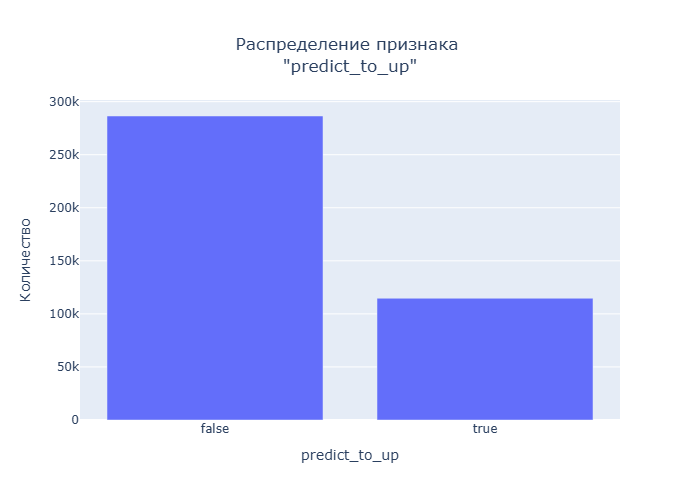

Статистические данные признака:


count     401206
unique         2
top        False
freq      286497
Name: predict_to_up, dtype: object

Top-10 значений (%):


predict_to_up
False    71.41
True     28.59
Name: proportion, dtype: float64

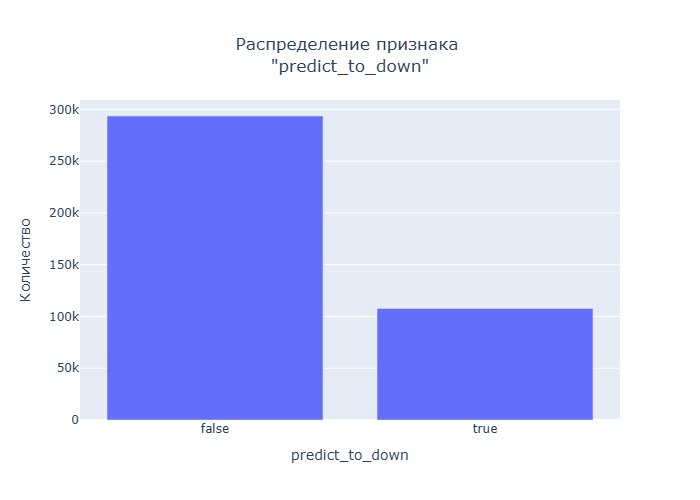

Статистические данные признака:


count     401206
unique         2
top        False
freq      293571
Name: predict_to_down, dtype: object

Top-10 значений (%):


predict_to_down
False    73.17
True     26.83
Name: proportion, dtype: float64

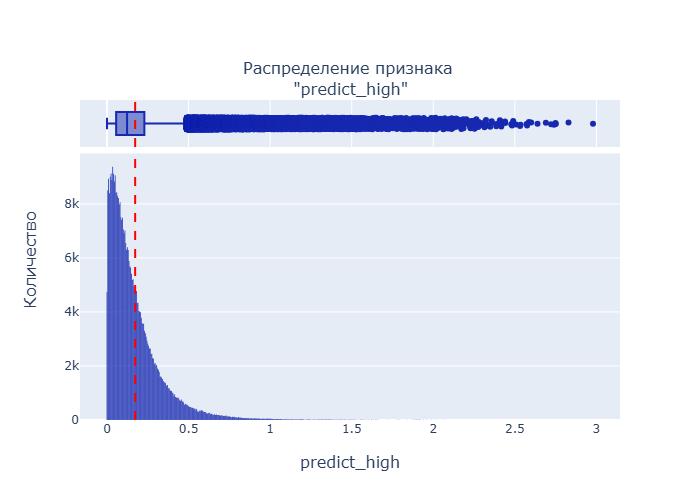

Статистические данные признака:


count    401206.00
mean          0.17
std           0.18
min           0.00
25%           0.06
50%           0.12
75%           0.23
max           2.98
Name: predict_high, dtype: float64

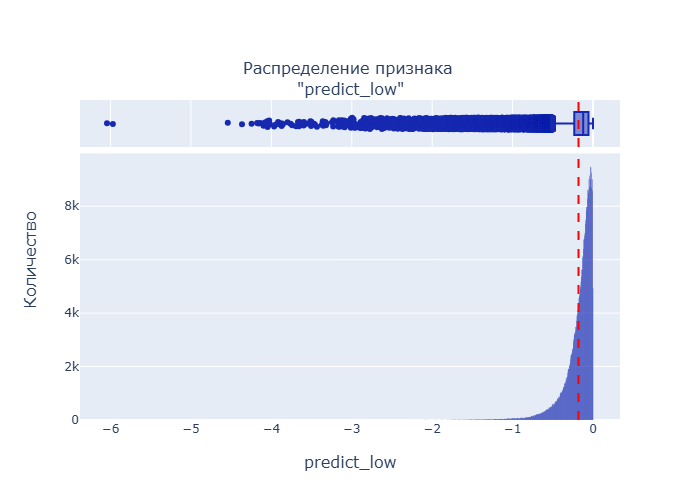

Статистические данные признака:


count    401206.00
mean         -0.18
std           0.21
min          -6.04
25%          -0.23
50%          -0.12
75%          -0.06
max           0.00
Name: predict_low, dtype: float64

In [57]:
# Построение гистограмм распределения целевых признаков
for col in ['predict_to_up', 'predict_to_down']:
    plot_categorical_feature(df_result, col, col)
for col in ['predict_high', 'predict_low']:
    plot_numerical_feature(df_result, col, col)

#### Оценка распределения признаков и вычисление выбросов.

In [58]:
normal = []
log_normal = []
unnormal = []
for col in df_result.columns:
    if col not in ['predict_high', 'predict_low', 'predict_to_up', 'predict_to_down',
                   'day_of_week_Monday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'day_of_week_Thursday', 'day_of_week_Friday']:
        _, p = stats.kstest(df_result[col], 'norm')
        if p > alpha:
            normal.append(col)
        else:
            _, p = stats.kstest(np.log(abs(df_result[col])+1), 'norm')
            if p > alpha:
                log_normal.append(col)
            else:
                unnormal.append(col)
print(f'Количество признаков, распределеных нормально: {len(normal)}')
print(f'Количество признаков, распределеных log-нормально: {len(log_normal)}')
print(f'Количество признаков, c распределением, отличным от нормального: {len(unnormal)}')

Количество признаков, распределеных нормально: 0
Количество признаков, распределеных log-нормально: 0
Количество признаков, c распределением, отличным от нормального: 96


Распределение всех числовых признаков отлично от нормального, исходя из этого для очистки от выбросов предпочтительно использовать метод Тьюки.

In [59]:
def outliers_iqr(data):
    quartile_1, quartile_3 = data.quantile(0.25), data.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * 3)
    upper_bound = quartile_3 + (iqr * 3)
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers.index

Очистке подвергнем признаки с высоким skew, так как очистка от выбросов по всем признакам приводит к сокращению количества записей более, чем на 10%.

Из очистки от выбросов исключаем целевые признаки, так как выбросы в них не имеют существенного влияния при обучении моделей на базе деревьев, а также признаки дней недели торгов и количества минут до пересчета индикаторов.

In [60]:
outliers_df_index = set()
exclude_col = ['predict_to_up', 'predict_to_down', 'predict_high', 'predict_low', 'min_to_next',
               'day_of_week_Monday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'day_of_week_Thursday',
               'day_of_week_Friday', 'month_day', 'month', 'hour']
for col in df_result.columns:
    if col not in exclude_col \
        and not pd.api.types.is_bool_dtype(df_result[col]):
        # Правосторонняя асимметрия распределения данных
        if df_result[col].skew() > 6 \
            and df_result[col].min() >= 0:
            outliers = outliers_iqr(np.log1p(df_result[col]))
            outliers_df_index.update(outliers)
        # Левосторонняя асимметрия распределения данных
        elif df_result[col].skew() < -6 \
            and df_result[col].max() <= 0:
            outliers = outliers_iqr(np.log1p(-df_result[col]))
            outliers_df_index.update(outliers)
            
df_clean = df_result.drop(index=sorted(outliers_df_index))
print(f"Удалено {len(outliers_df_index)} выбросов.")

Удалено 21580 выбросов.


In [61]:
df_clean.shape

(379626, 105)

Таким образом, выборка df_clean содержит очищенные данные. Ввиду особенностей распределений значений признаков, для очистки применялся более мягкий подход, что обеспечило уменьшение количества записей в пределах 6%, что позволяет сохранить репрезентативность выборки.

#### Оценка степени мультиколлинеарности признаков

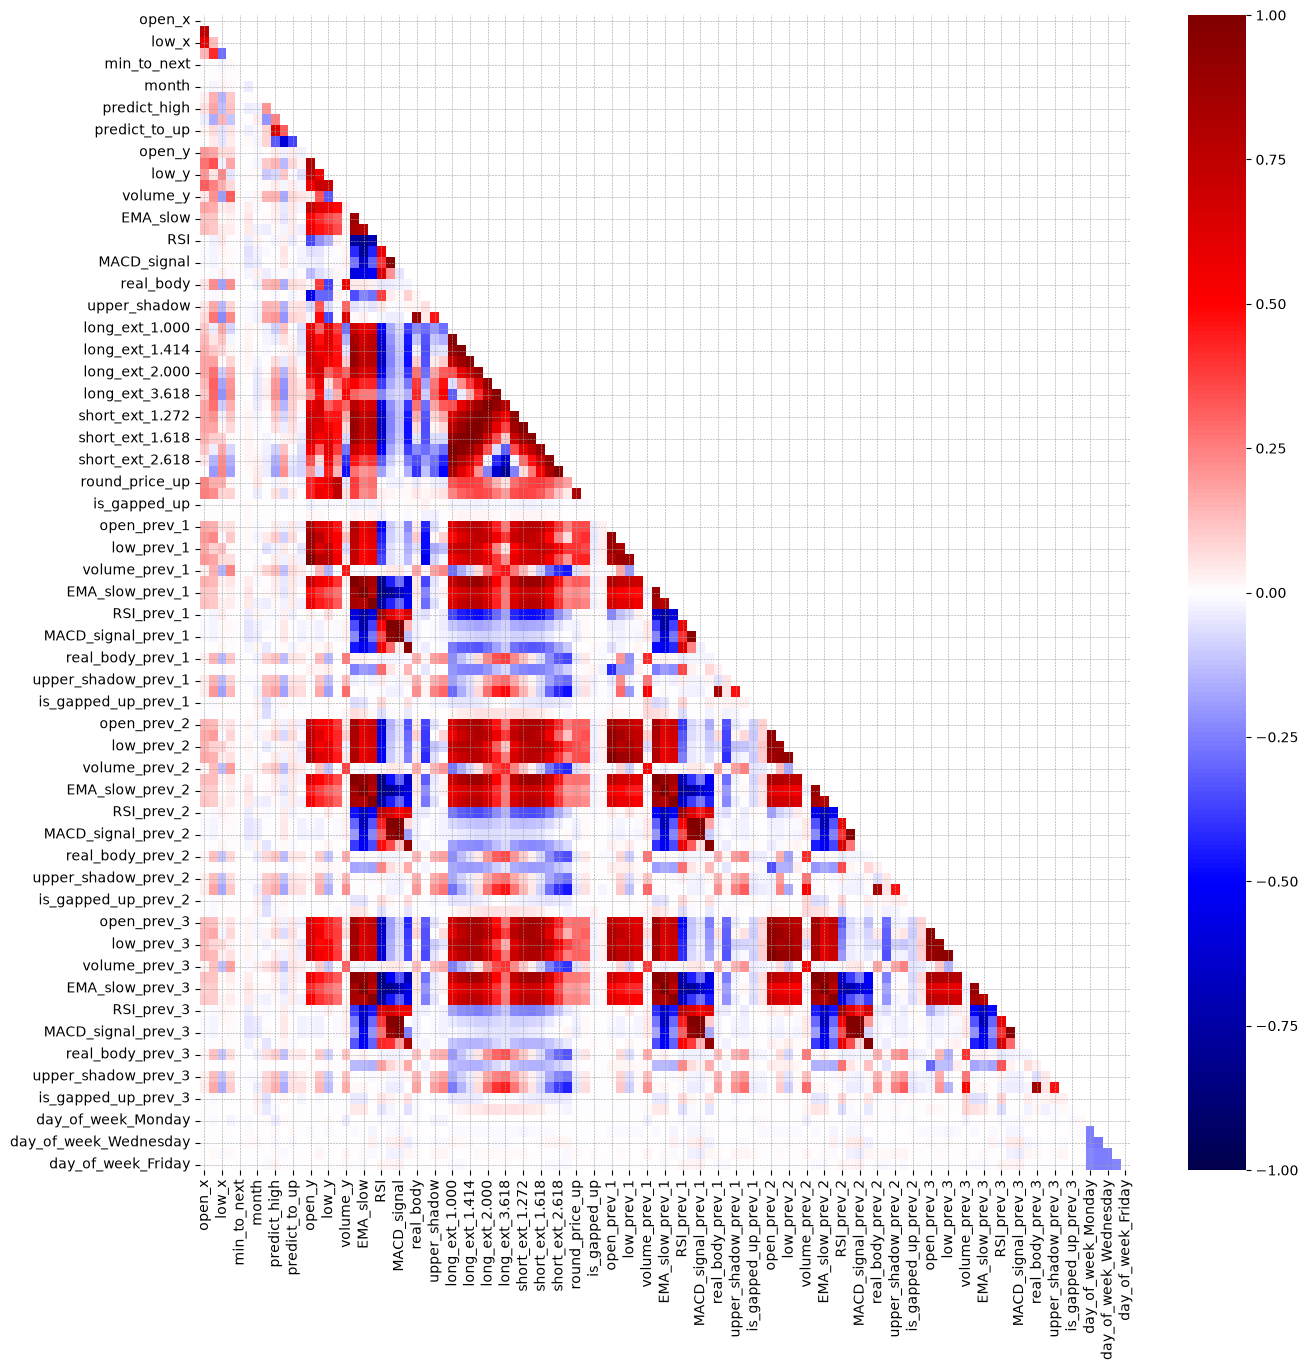

In [62]:
# Построение корреляционной матрицы
lst_target = ['predict_to_up', 'predict_to_down', 'predict_high', 'predict_low']
df_corr = df_clean.drop(columns=lst_target).corr(method='pearson', numeric_only=True)
# Матрица корреляций
plt.figure(figsize=(15, 15))
sns.heatmap(df_clean.corr(numeric_only=True),
            annot=False, # Подпись данных
            annot_kws = {'size':5},
            vmin=-1, vmax=1,
            center=0,
            cmap='seismic',
            mask=np.triu(df_clean.corr(numeric_only=True)))
plt.show()

Модели на основе деревьев устойчивы к мультиколлинеарности и автоматически выбирают более информативные признаки, также в случаях дискретного влияния значений различных признаков на целевые показатели (то есть при схожих значениях двух признаков по всей выборке, но различающихся только в некоторых количествах записей, именно эта разница может оказывать влияние на прогностические модели при определении ценового движения), поэтому порог для удаления сильно коррелирующих признаков увеличиваем до **0.8**.

In [63]:
# Подсчет количества сильно коррелирующих признаков для каждого признака из пар
dict_strong_corr_features = {}
for i in range(1, df_corr.shape[0]):
    for j in range(0, i):
        if abs(df_corr.iloc[i, j]) >= corr_limit:
            dict_strong_corr_features[df_corr.index[i]] = dict_strong_corr_features.get(df_corr.index[i], 0) + 1
            dict_strong_corr_features[df_corr.columns[j]] = dict_strong_corr_features.get(df_corr.columns[j], 0) + 1
# Сортировка полученных значений
dict_strong_corr_features = dict(sorted(dict_strong_corr_features.items(), key=lambda x: x[1], reverse=True))

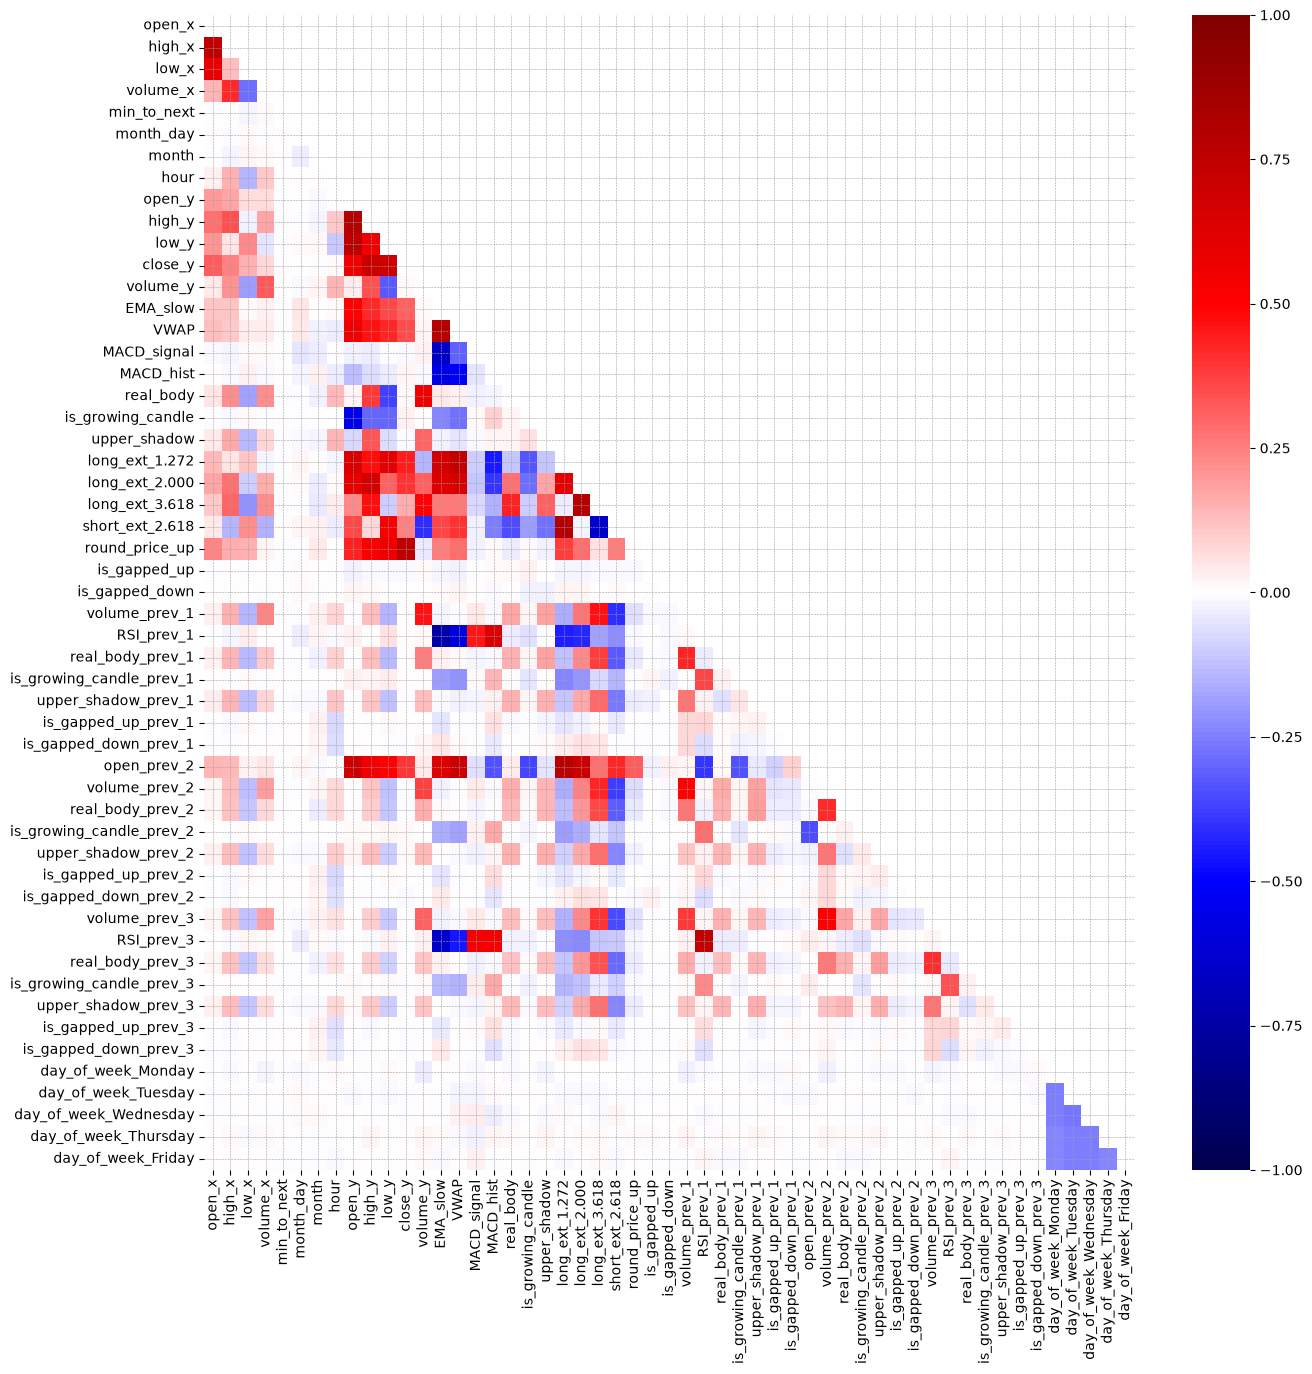

In [64]:
# Очистка от сильно коррелирующих признаков
df_cleaned_strong_corr = df_clean.drop(columns=lst_target)
while len(dict_strong_corr_features) > 0:
    # Удаление наиболее встречающегося сильно скорр. признака
    df_cleaned_strong_corr.drop(next(iter(dict_strong_corr_features)), axis=1, inplace=True)
    # Пересчет матрицы корреляций и вычисление следующего признака для удаления
    df_corr = df_cleaned_strong_corr.corr(method='pearson', numeric_only=True)
    # Подсчет количества сильно коррелирующих признаков для каждого признака из пар
    dict_strong_corr_features.clear()
    for i in range(1, df_corr.shape[0]):
        for j in range(0, i):
            if abs(df_corr.iloc[i, j]) >= corr_limit:
                dict_strong_corr_features[df_corr.index[i]] = dict_strong_corr_features.get(df_corr.index[i], 0) + 1
                dict_strong_corr_features[df_corr.columns[j]] = dict_strong_corr_features.get(df_corr.columns[j], 0) + 1
    # Сортировка полученных значений
    dict_strong_corr_features = dict(sorted(dict_strong_corr_features.items(), key=lambda x: x[1], reverse=True))

# Матрица корреляций
plt.figure(figsize=(15, 15))
sns.heatmap(df_cleaned_strong_corr.corr(numeric_only=True),
            annot=False, # Подпись данных
            annot_kws = {'size':5},
            vmin=-1, vmax=1,
            center=0,
            cmap='seismic',
            mask=np.triu(df_cleaned_strong_corr.corr(numeric_only=True)))
plt.show()

In [65]:
df_cleaned_strong_corr.shape[1]

53

In [66]:
df_cleaned_strong_corr.columns

Index(['open_x', 'high_x', 'low_x', 'volume_x', 'min_to_next', 'month_day',
       'month', 'hour', 'open_y', 'high_y', 'low_y', 'close_y', 'volume_y',
       'EMA_slow', 'VWAP', 'MACD_signal', 'MACD_hist', 'real_body',
       'is_growing_candle', 'upper_shadow', 'long_ext_1.272', 'long_ext_2.000',
       'long_ext_3.618', 'short_ext_2.618', 'round_price_up', 'is_gapped_up',
       'is_gapped_down', 'volume_prev_1', 'RSI_prev_1', 'real_body_prev_1',
       'is_growing_candle_prev_1', 'upper_shadow_prev_1',
       'is_gapped_up_prev_1', 'is_gapped_down_prev_1', 'open_prev_2',
       'volume_prev_2', 'real_body_prev_2', 'is_growing_candle_prev_2',
       'upper_shadow_prev_2', 'is_gapped_up_prev_2', 'is_gapped_down_prev_2',
       'volume_prev_3', 'RSI_prev_3', 'real_body_prev_3',
       'is_growing_candle_prev_3', 'upper_shadow_prev_3',
       'is_gapped_up_prev_3', 'is_gapped_down_prev_3', 'day_of_week_Monday',
       'day_of_week_Tuesday', 'day_of_week_Wednesday', 'day_of_week_Thursda

In [67]:
df_cleaned_strong_corr = df_clean[list(df_cleaned_strong_corr.columns)+lst_target]
df_cleaned_strong_corr.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 379626 entries, 2022-08-02 10:45:00 to 2026-07-31 16:59:00
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   open_x                    379626 non-null  float64
 1   high_x                    379626 non-null  float64
 2   low_x                     379626 non-null  float64
 3   volume_x                  379626 non-null  int64  
 4   min_to_next               379626 non-null  int64  
 5   month_day                 379626 non-null  int32  
 6   month                     379626 non-null  int32  
 7   hour                      379626 non-null  int32  
 8   open_y                    379626 non-null  float64
 9   high_y                    379626 non-null  float64
 10  low_y                     379626 non-null  float64
 11  close_y                   379626 non-null  float64
 12  volume_y                  379626 non-null  float64
 13  EMA_slow  

После удаления сильно скоррелированных признаков датасет содержит 57 признаков, что в том числе обеспечит экономию времени на обучение моделей и подбор гиперпараметров.

---

## Объединение датасетов изменения цены активов и сообщений новостного канала

При объединении полученных датасетов необходимо также обеспечить репрезентативность выборки сообщений на каждом объекте (записи). Для этого к каждой записи добавим признаки двух последних сообщений, а также "корректирующие" признаки "свежести" этих сообщений - количество минут, прошедших с момента публикации новости.

Так как было определено, что только по ценовым данным определить целевые параметры затруднительно, а в качестве "разворотных" факторов обычно выступают новостные сообщения, то объединение факторов необходимо производить относительно датасета с новостями.

In [68]:
# Округление индекса датасета сообщений до минуты вниз
df_msgs_full.index = df_msgs_full.index.floor('min')
# Копирование времени сообщения из индекса
df_msgs_full['dt'] = df_msgs_full.index

In [69]:
# Проверка на дубликаты в индексах
df_msgs_full.index.duplicated().sum()

np.int64(4213)

Так как новостные сообщения могут выходить чаще, чем раз в минуту, то после округления значений индексов в датасете образовались дубликаты. Порядок сообщений сохранен в соответствии с их публикацией, время публикации сохранено в отдельный признак. Далее обеспечиваем ретростпективность сообщений и объединяем с информацией о котировках.

In [70]:
lst_columns = df_msgs_full.columns.to_list()
shifted_cols = {}
# Формирование словаря с предыдущими сообщениями
for sign in lst_columns:
    # Pandas при использовании shift на Series типа bool возвращает object,
    # добавляем дополнительное преобразование
    base_series = df_msgs_full[sign]
    is_bool = pd.api.types.is_bool_dtype(base_series)
    for i in range(1, count_previous_messages + 1):
        s = base_series.shift(i)
        if is_bool:
            s = s.convert_dtypes()
        shifted_cols[f'{sign}_prev_{i}'] = s
# Преобразование словаря в Dataframe и объединение
df_shifts = pd.DataFrame(shifted_cols)
df_msgs_full = pd.concat([df_msgs_full, df_shifts], axis=1)
df_msgs_full.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 153452 entries, 2022-08-01 07:33:00 to 2026-07-31 22:06:00
Columns: 111 entries, #геополитика to dt_prev_2
dtypes: bool(18), boolean(36), datetime64[ns](3), float32(12), float64(28), int64(14)
memory usage: 78.1 MB


In [71]:
# Формирование признака "минут со времени публикации предыдущей новости"
df_msgs_full['min_passed_prev_1'] = (df_msgs_full['dt'] - df_msgs_full['dt_prev_1']).dt.total_seconds() // 60
df_msgs_full['min_passed_prev_2'] = (df_msgs_full['dt'] - df_msgs_full['dt_prev_2']).dt.total_seconds() // 60

После формирования признаков актуальности предыдущих новостей удаляем время их публикации 'dt_prev_1' и 'dt_prev_2', избавляемся от дубликатов индексов, сбрасывая его, а также удаляем записи с пропущенными значениями. Признаки 'min_passed_prev_1' и 'min_passed_prev_2' преобразуем в тип int.

In [72]:
df_msgs_full.dropna(axis=0, inplace=True)
df_msgs_full.drop(columns=['dt_prev_1', 'dt_prev_2'], inplace=True)
df_msgs_full['min_passed_prev_1'].astype(int)
df_msgs_full['min_passed_prev_2'].astype(int)
df_msgs_full.reset_index(drop=True, inplace=True)
df_msgs_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153450 entries, 0 to 153449
Columns: 111 entries, #геополитика to min_passed_prev_2
dtypes: bool(18), boolean(36), datetime64[ns](1), float32(12), float64(30), int64(14)
memory usage: 72.9 MB


Объединяем датасеты.

In [73]:
df_result = df_msgs_full.merge(df_cleaned_strong_corr,
                               left_on='dt',
                               right_index=True, # использование индекса df_cleaned_strong_corr как ключ для присоединения
                               how='left')       # оставляем все сообщения, если свечи нет — NaN
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153450 entries, 0 to 153449
Columns: 168 entries, #геополитика to predict_low
dtypes: bool(18), boolean(53), datetime64[ns](1), float32(12), float64(68), int64(14), object(2)
memory usage: 124.7+ MB


In [74]:
# Получение признаков с типом object 
df_result.select_dtypes(include=['object']).columns.tolist()

['predict_to_up', 'predict_to_down']

In [75]:
# Проверка на пропуски
df_result.isna().sum(axis=0)

#геополитика              0
#отчетность               0
#прогноз                  0
#экономика                0
#дкп                      0
                      ...  
day_of_week_Friday    92606
predict_to_up         92606
predict_to_down       92606
predict_high          92606
predict_low           92606
Length: 168, dtype: int64

Проверка на пропуски показывает, что в результирующем датасете присутствуют сообщения без данных о котировках на момент выхода новости. Это произошло в результате того, что при формировании датасета финансовых котировок была произведена фильтрация по времени проведения торгов. Соответственно, итоговый датасет можно просто очистить от строк с пропусками, так как они не должны были войти в выборку для формирования и оценки моделей по условиям кейса.  
Также в датасете присутствует колонка 'dt, которая для нас более не представляет интереса также должна быть удалена.

In [76]:
# Очистка от пропущенных значений со сбросом индекса
df_result = df_result.dropna(axis=0).reset_index(drop=True)
# Удаление столбца dt
df_result.drop(columns=['dt'], inplace=True)

df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60844 entries, 0 to 60843
Columns: 167 entries, #геополитика to predict_low
dtypes: bool(18), boolean(53), float32(12), float64(68), int64(14), object(2)
memory usage: 49.0+ MB


Таким образом на данном этапе получен очищенный датасет, включающий в себя 60844 записи по четырем целевым признакам и 163 факторам, пригодным для обучения моделей ML. В целевых признаках наблюдается дисбаланс, данный факт будет учтен при формировании моделей.

---

## Формирование и оценка моделей

Несмотря на формат подготовленных данных, они больше всего по своим свойствам схожи с временными рядами, поэтому при разбиении на тренировочную и тестовые выборки наиболее оптимально отказаться от стратификации и перемешивания для предотвращения утечки данных при обучении моделей.

In [77]:
# Выделение целевых признаков
y_high = df_result['predict_high']
y_low = df_result['predict_low']
y_to_up = df_result['predict_to_up'].astype(bool)
y_to_down = df_result['predict_to_down'].astype(bool)
X = df_result.drop(columns=['predict_high', 'predict_low', 'predict_to_up', 'predict_to_down'])

In [78]:
def metrics_print(model, X_tr, X_tst, y_tr, y_tst, threshold=0.5):
    '''Функция вывода оценок точности, полноты и f1-меры модели
       на тренировочных и тестовых данных, с учетом порога принятия
       решения '''
    if threshold == 0.5:
        y_pred_train = model.predict(X_tr)
        y_pred_test = model.predict(X_tst)
        # Получение метрик модели
        print('-------На тренировочных данных-------')
        print(f'Точность: {metrics.precision_score(y_tr, y_pred_train):.4f}    Полнота: {metrics.recall_score(y_tr, y_pred_train):.4f}    F1: {metrics.f1_score(y_tr, y_pred_train):.4f}')
        print('-------На тестовых данных------------')
        print(f'Точность: {metrics.precision_score(y_tst, y_pred_test):.4f}    Полнота: {metrics.recall_score(y_tst, y_pred_test):.4f}    F1: {metrics.f1_score(y_tst, y_pred_test):.4f}')
    else:
        # Получение прогноза с порогом принятия решения threshold
        y_pred_train_proba = model.predict_proba(X_tr)[:, 1]
        y_pred_train = (y_pred_train_proba > threshold).astype('int')
        
        y_pred_test_proba = model.predict_proba(X_tst)[:, 1]
        y_pred_test = (y_pred_test_proba > threshold).astype('int')
        # Получение метрик модели
        print(f'Порог принятия решения: {threshold}')
        print('-------На тренировочных данных-------')
        print(f'Точность: {metrics.precision_score(y_tr, y_pred_train):.4f}    Полнота: {metrics.recall_score(y_tr, y_pred_train):.4f}    F1: {metrics.f1_score(y_tr, y_pred_train):.4f}')
        print('-------На тестовых данных------------')
        print(f'Точность: {metrics.precision_score(y_tst, y_pred_test):.4f}    Полнота: {metrics.recall_score(y_tst, y_pred_test):.4f}    F1: {metrics.f1_score(y_tst, y_pred_test):.4f}')

#### Прогнозирование направления движения цены вверх

Обучение и оценка baseline-модели.

In [79]:
# Разбивка данных на тренировочную и тестовую выборки
X_train_up, X_test_up, y_train_up, y_test_up = train_test_split(X, y_to_up, test_size=0.2, shuffle=False, random_state=rs)
# Размерности выборок
print(f'Размерность обучающей выборки {X_train_up.shape}')
print(f'Размерность тестовой выборки {X_test_up.shape}')

Размерность обучающей выборки (48675, 163)
Размерность тестовой выборки (12169, 163)


In [80]:
# Создание модели случайного леса
model_to_up = RandomForestClassifier(n_estimators=100,    # 100 деревьев
                                     max_depth=10,        # ограничение глубины
                                     max_features='sqrt', # ограничение количества признаков, предотвращает переобучение
                                     min_samples_leaf=5,  # минимальное количество экземпляров в листе
                                     n_jobs=-1,
                                     random_state=rs)
# Обучение модели
model_to_up.fit(X_train_up, y_train_up)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
metrics_print(model_to_up, X_tr=X_train_up, X_tst=X_test_up, y_tr=y_train_up, y_tst=y_test_up)

-------На тренировочных данных-------
Точность: 1.0000    Полнота: 0.0323    F1: 0.0625
-------На тестовых данных------------
Точность: 0.4769    Полнота: 0.0077    F1: 0.0152


In [82]:
# Создание модели xgb
model_to_up = XGBClassifier(n_estimators=100,    # 100 деревьев
                            max_depth=10,        # ограничение глубины
                            random_state=rs)
# Обучение модели
model_to_up.fit(X_train_up, y_train_up)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [83]:
metrics_print(model_to_up, X_tr=X_train_up, X_tst=X_test_up, y_tr=y_train_up, y_tst=y_test_up)

-------На тренировочных данных-------
Точность: 1.0000    Полнота: 0.9999    F1: 0.9999
-------На тестовых данных------------
Точность: 0.3965    Полнота: 0.1709    F1: 0.2389


Baseline-модели показывают высокие оценки на тренировочных данных, но достаточно низкие на тестовых, что показывает достаточно высокую степень переобученности полученных моделей, характерную для первых итераций.

#### Подбор гиперпараметров модели "Прогнозирования направления движения цены вверх"

In [84]:
# Пространство поиска гиперпараметров
space_up = {"learning_rate": hp.choice('learning_rate', [0.01, 0.03, 0.05, 0.1]),
            "n_estimators": hp.choice('n_estimators', [100, 300, 500, 1000]),
            "max_depth": hp.choice('max_depth', [3, 4, 5, 6, 7, 8]),
            "min_child_weight": hp.loguniform("min_child_weight", np.log(0.1), np.log(10)),
            "subsample": hp.uniform("subsample", 0.6, 1.0),
            "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
            "gamma": hp.loguniform("gamma", np.log(1e-8), np.log(5.0)),
            "reg_alpha": hp.loguniform("reg_alpha", np.log(1e-8), np.log(10.0)),
            "reg_lambda": hp.loguniform("reg_lambda", np.log(1e-8), np.log(10.0)),
            # Балансировка классов – широкий диапазон
            "scale_pos_weight": hp.choice("scale_pos_weight", [1, 2, 2.5, 3, 4]),
            "objective": "binary:logistic",
            'tree_method': 'hist',
            "eval_metric": "aucpr",
            "random_state": rs,
            "n_jobs": 4}

In [85]:
def hyperopt_up(params, cv=5, X=X_train_up, y=y_train_up):
    '''Функция подбора гиперпараметров модели прогнозирования движения цены вверх'''
    params["n_estimators"] = int(params["n_estimators"])
    params["max_depth"]    = int(params["max_depth"])
    # Объявление модели
    model = XGBClassifier(**params)
    # Обучение модели с использованием кросс‑валидации
    cvs = TimeSeriesSplit(n_splits=cv)
    scores = cross_val_score(model, X, y,
                             cv=cvs,
                             # Оценка с акцентом на точность
                             scoring=metrics.make_scorer(metrics.fbeta_score, beta=0.5),
                             n_jobs=1)
    mean_score = scores.mean()
    # Возвращение результата 
    return {'loss': -mean_score, # оценка
            'status': STATUS_OK, # статус обучения
            'params': params}    # параметры

In [86]:
# Подбор гиперпараметров
trials_up = Trials() # логирование результатов

if recalculating_model_to_up:
    best_up=fmin(hyperopt_up,      # функция 
                 space=space_up,   # пространство гиперпараметров
                 algo=tpe.suggest, # алгоритм оптимизации
                 max_evals=50,     # максимальное количество итераций
                 trials=trials_up, # логирование результатов
                 rstate=np.random.default_rng(rs))

100%|██████████| 50/50 [10:24<00:00, 12.49s/trial, best loss: -0.34177125831737104]


In [87]:
# Вывод результатов подбора
if recalculating_model_to_up:
    best_trial_up = trials_up.best_trial
    params_up = best_trial_up['result']['params']
    print("\n=== Параметры ===")
    print(best_trial_up['result']['params'])
    print("\n=== Средний CV-score ===")
    print(-best_trial_up['result']['loss'])
else:
    params_up = {'colsample_bytree': 0.7834548475717842, 
                 'eval_metric': 'aucpr', 
                 'gamma': 1.515883811332838e-08, 
                 'learning_rate': 0.01, 
                 'max_depth': 4, 
                 'min_child_weight': 1.4950706024321256, 
                 'n_estimators': 300, 
                 'n_jobs': 4, 
                 'objective': 'binary:logistic', 
                 'random_state': 42, 
                 'reg_alpha': 0.2478298443152855, 
                 'reg_lambda': 2.352667564496581e-05, 
                 'scale_pos_weight': 3, 
                 'subsample': 0.6537123485932513, 
                 'tree_method': 'hist'}
    print('Параметры модели не пересчитывались\nСредний CV-score (fbeta_score) 0.34177125831737104')
# Обучение итоговой модели
model_to_up_hyp_res = XGBClassifier(**params_up)
model_to_up_hyp_res.fit(X_train_up, y_train_up)


=== Параметры ===
{'colsample_bytree': 0.7834548475717842, 'eval_metric': 'aucpr', 'gamma': 1.515883811332838e-08, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 1.4950706024321256, 'n_estimators': 300, 'n_jobs': 4, 'objective': 'binary:logistic', 'random_state': 42, 'reg_alpha': 0.2478298443152855, 'reg_lambda': 2.352667564496581e-05, 'scale_pos_weight': 3, 'subsample': 0.6537123485932513, 'tree_method': 'hist'}

=== Средний CV-score ===
0.34177125831737104


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7834548475717842
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


Подбор гиперпараметров был проведен ранее, итоговые параметры зафиксированы в **params_up**, для пересчета установить **recalculating_model_to_up** в значение **True**.

In [88]:
metrics_print(model_to_up_hyp_res, X_tr=X_train_up, X_tst=X_test_up, y_tr=y_train_up, y_tst=y_test_up)

-------На тренировочных данных-------
Точность: 0.3512    Полнота: 0.7650    F1: 0.4814
-------На тестовых данных------------
Точность: 0.3454    Полнота: 0.8859    F1: 0.4970


Полученная модель показывает качество на тестовых данных не хуже, а даже немного лучше, чем на тренировочных, что подтверждает отсутствие признаков утечки и явного переобучения.  
Текущая модель показывает достаточно высокую полноту выявления торговых сигналов, но при этом выдает большое количество количество ложных.  

Для торговой задачи точность в 35% может быть вполне приемлемой и компенсироваться грамотно построенным риск-менеджементом, реальная оценка должна проводиться с учетом стоимостей удачных и неудачных сделок, так как на данном этапе эти сведения отсутствуют, проведем оптимизацию порога принятия решения.

Best threshold = 0.52, F1-Score = 0.49


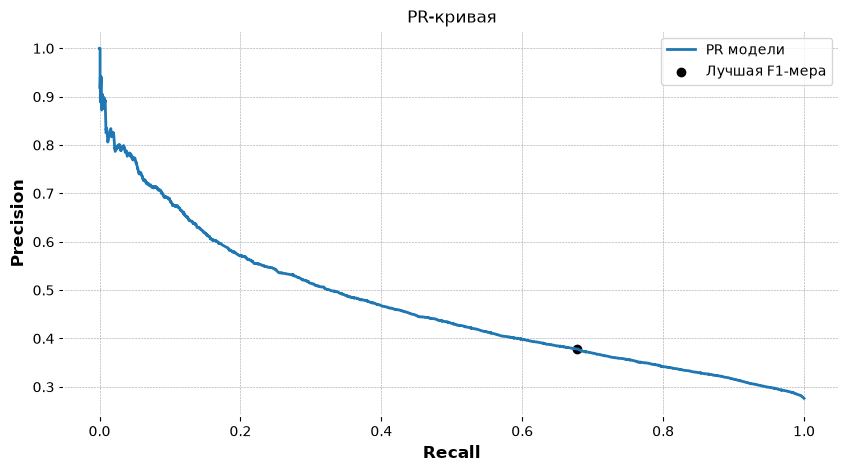

In [89]:
# Выделение столбца с вероятностями для класса 1 
y_cv_proba_pred = model_to_up_hyp_res.predict_proba(X_train_up)[:, 1]
# Вычисление координат PR-кривой
precision, recall, thresholds = metrics.precision_recall_curve(y_train_up, y_cv_proba_pred)

# Вычисление F1-меры при различных threshold
f1_scores = (2 * precision * recall) / (precision + recall)
# Определение индекса максимума
idx = np.argmax(f1_scores)
print('Best threshold = {:.2f}, F1-Score = {:.2f}'.format(thresholds[idx], f1_scores[idx]))

# Построение PR-кривой
fig, ax = plt.subplots(figsize=(10, 5))
# Линейный график зависимости precision от recall
ax.plot(recall, precision, label='PR модели')
# Точка максимума F1
ax.scatter(recall[idx], precision[idx], marker='o', color='black', label='Лучшая F1-мера')
ax.set_title('PR-кривая')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
# Отображение легенды
ax.legend();

In [90]:
metrics_print(model_to_up_hyp_res, X_tr=X_train_up, X_tst=X_test_up, y_tr=y_train_up, y_tst=y_test_up)

-------На тренировочных данных-------
Точность: 0.3512    Полнота: 0.7650    F1: 0.4814
-------На тестовых данных------------
Точность: 0.3454    Полнота: 0.8859    F1: 0.4970


In [91]:
metrics_print(model_to_up_hyp_res, X_tr=X_train_up, X_tst=X_test_up, y_tr=y_train_up, y_tst=y_test_up, threshold=0.52)

Порог принятия решения: 0.52
-------На тренировочных данных-------
Точность: 0.3759    Полнота: 0.6820    F1: 0.4847
-------На тестовых данных------------
Точность: 0.3555    Полнота: 0.7977    F1: 0.4919


Основываясь на pr-кривой, получено значение порога принятия решения **0.52**, повышающий точность прогноза, но несколько снижающий полноту, а, следовательно, и количество подаваемых сигналов. Поэтому при подготовке модели в продакшн значение порога принятия решения разумно вынести как доступный для изменения пользователем параметр с установленным рекомендованным значением.

#### Прогнозирование направления движения цены вниз

Обучение и оценка baseline-модели.

In [92]:
# Разбивка данных на тренировочную и тестовую выборки
X_train_down, X_test_down, y_train_down, y_test_down = train_test_split(X, y_to_down, test_size=0.2, shuffle=False, random_state=rs)
# Размерности выборок
print(f'Размерность обучающей выборки {X_train_down.shape}')
print(f'Размерность тестовой выборки {X_test_down.shape}')

Размерность обучающей выборки (48675, 163)
Размерность тестовой выборки (12169, 163)


In [93]:
# Создание модели случайного леса
model_to_down = RandomForestClassifier(n_estimators=100,    # 100 деревьев
                                       max_depth=10,        # ограничение глубины
                                       max_features='sqrt', # ограничение количества признаков, предотвращает переобучение
                                       min_samples_leaf=5,  # минимальное количество экземпляров в листе
                                       n_jobs=-1,
                                       random_state=rs)
# Обучение модели
model_to_down.fit(X_train_down, y_train_down)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [94]:
metrics_print(model_to_down, X_tr=X_train_down, X_tst=X_test_down, y_tr=y_train_down, y_tst=y_test_down)

-------На тренировочных данных-------
Точность: 1.0000    Полнота: 0.0094    F1: 0.0186
-------На тестовых данных------------
Точность: 0.0000    Полнота: 0.0000    F1: 0.0000


In [95]:
# Создание модели xgb
model_to_down = XGBClassifier(n_estimators=100,    # 100 деревьев
                              max_depth=10,        # ограничение глубины
                              random_state=rs)
# Обучение модели
model_to_down.fit(X_train_down, y_train_down)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [96]:
metrics_print(model_to_down, X_tr=X_train_down, X_tst=X_test_down, y_tr=y_train_down, y_tst=y_test_down)

-------На тренировочных данных-------
Точность: 1.0000    Полнота: 1.0000    F1: 1.0000
-------На тестовых данных------------
Точность: 0.3617    Полнота: 0.1106    F1: 0.1694


Baseline-модели показывают высокие оценки на тренировочных данных, но достаточно низкие на тестовых, что показывает достаточно высокую степень переобученности полученных моделей, характерную для первых итераций.

#### Подбор гиперпараметров модели "Прогнозирование направления движения цены вниз"

In [97]:
# Пространство поиска гиперпараметров
space_down = {"learning_rate": hp.choice('learning_rate', [0.01, 0.03, 0.05, 0.1]),
              "n_estimators": hp.choice('n_estimators', [100, 300, 500, 1000]),
              "max_depth": hp.choice('max_depth', [3, 4, 5, 6, 7, 8]),
              "min_child_weight": hp.loguniform("min_child_weight", np.log(0.1), np.log(10)),
              "subsample": hp.uniform("subsample", 0.6, 1.0),
              "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
              "gamma": hp.loguniform("gamma", np.log(1e-8), np.log(5.0)),
              "reg_alpha": hp.loguniform("reg_alpha", np.log(1e-8), np.log(10.0)),
              "reg_lambda": hp.loguniform("reg_lambda", np.log(1e-8), np.log(10.0)),
              # Балансировка классов – широкий диапазон
              "scale_pos_weight": hp.choice("scale_pos_weight", [1, 2, 2.5, 3, 4]),
              "objective": "binary:logistic",
              'tree_method': 'hist',
              "eval_metric": "aucpr",
              "random_state": rs,
              "n_jobs": 4}

In [98]:
def hyperopt_down(params, cv=5, X=X_train_down, y=y_train_down):
    '''Функция подбора гиперпараметров модели прогнозирования движения цены вниз'''
    params["n_estimators"] = int(params["n_estimators"])
    params["max_depth"]    = int(params["max_depth"])
    # Объявление модели
    model = XGBClassifier(**params)
    # Обучение модели с использованием кросс‑валидации
    cvs = TimeSeriesSplit(n_splits=cv)
    scores = cross_val_score(model, X, y,
                             cv=cvs,
                             # Оценка с акцентом на точность
                             scoring=metrics.make_scorer(metrics.fbeta_score, beta=0.5),
                             n_jobs=1)
    mean_score = scores.mean()
    # Возвращение результата
    return {'loss': -mean_score, # оценка
            'status': STATUS_OK, # статус обучения
            'params': params}    # параметры

In [99]:
# Подбор гиперпараметров
trials_down = Trials() # логирование результатов

if recalculating_model_to_down:
    best_down=fmin(hyperopt_down,      # функция 
                   space=space_down,   # пространство гиперпараметров
                   algo=tpe.suggest,   # алгоритм оптимизации
                   max_evals=50,       # максимальное количество итераций
                   trials=trials_down, # логирование результатов
                   rstate=np.random.default_rng(rs))

100%|██████████| 50/50 [08:45<00:00, 10.52s/trial, best loss: -0.3219060529677706] 


In [100]:
# Вывод результатов подбора
if recalculating_model_to_down:
    best_trial_down = trials_down.best_trial
    params_down = best_trial_down['result']['params']
    print("\n=== Параметры ===")
    print(best_trial_down['result']['params'])
    print("\n=== Средний CV-score ===")
    print(-best_trial_down['result']['loss'])
else:
    params_down = {'colsample_bytree': 0.6199718695157638, 
                   'eval_metric': 'aucpr', 
                   'gamma': 1.7306486112564703e-07, 
                   'learning_rate': 0.01, 
                   'max_depth': 5, 
                   'min_child_weight': 6.638994410792433, 
                   'n_estimators': 100, 
                   'n_jobs': 4, 
                   'objective': 'binary:logistic', 
                   'random_state': 42, 
                   'reg_alpha': 8.178277068077685, 
                   'reg_lambda': 0.4585456366251626, 
                   'scale_pos_weight': 3, 
                   'subsample': 0.7952729628357851, 
                   'tree_method': 'hist'}
    print('Параметры модели не пересчитывались\nСредний CV-score (fbeta_score) 0.3219060529677706')
# Обучение итоговой модели
model_to_down_hyp_res = XGBClassifier(**params_down)
model_to_down_hyp_res.fit(X_train_down, y_train_down)


=== Параметры ===
{'colsample_bytree': 0.6199718695157638, 'eval_metric': 'aucpr', 'gamma': 1.7306486112564703e-07, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 6.638994410792433, 'n_estimators': 100, 'n_jobs': 4, 'objective': 'binary:logistic', 'random_state': 42, 'reg_alpha': 8.178277068077685, 'reg_lambda': 0.4585456366251626, 'scale_pos_weight': 3, 'subsample': 0.7952729628357851, 'tree_method': 'hist'}

=== Средний CV-score ===
0.3219060529677706


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6199718695157638
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


Подбор гиперпараметров был проведен ранее, итоговые параметры зафиксированы в **params_down**, для пересчета установить **recalculating_model_to_down** в значение **True**.

In [101]:
metrics_print(model_to_down_hyp_res, X_tr=X_train_down, X_tst=X_test_down, y_tr=y_train_down, y_tst=y_test_down)

-------На тренировочных данных-------
Точность: 0.3503    Полнота: 0.6710    F1: 0.4603
-------На тестовых данных------------
Точность: 0.3499    Полнота: 0.7479    F1: 0.4768


Полученная модель показывает качество на тестовых данных не хуже, а даже немного лучше, чем на тренировочных, что подтверждает отсутствие признаков утечки и явного переобучения.  
Текущая модель показывает достаточно высокую полноту выявления торговых сигналов, но при этом выдает большое количество количество ложных.  

Для торговой задачи точность в 35% может быть вполне приемлемой и компенсироваться грамотно построенным риск-менеджементом, реальная оценка должна проводиться с учетом стоимостей удачных и неудачных сделок, так как на данном этапе эти сведения отсутствуют, проведем оптимизацию порога принятия решения.

Best threshold = 0.49, F1-Score = 0.46


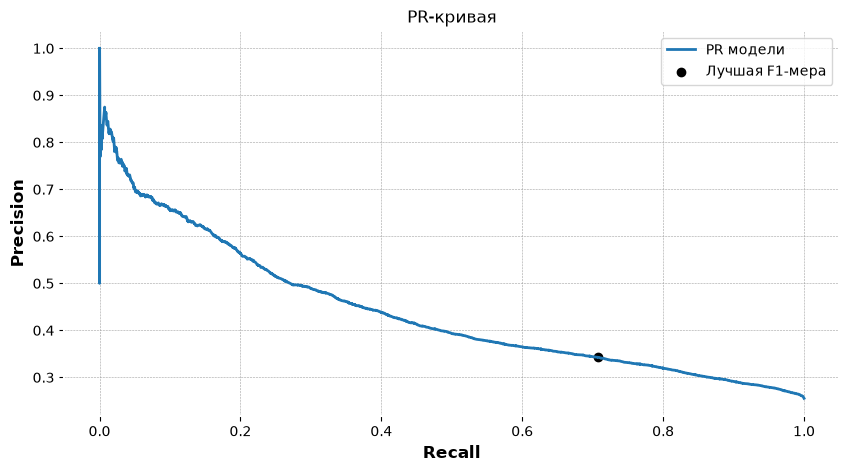

In [102]:
# Выделение столбца с вероятностями для класса 1
y_cv_proba_pred = model_to_down_hyp_res.predict_proba(X_train_down)[:,1]
# Вычисление координат PR-кривой
precision, recall, thresholds = metrics.precision_recall_curve(y_train_down, y_cv_proba_pred)

# Вычисление F1-меры при различных threshold
f1_scores = (2 * precision * recall) / (precision + recall)
# Определение индекса максимума
idx = np.argmax(f1_scores)
print('Best threshold = {:.2f}, F1-Score = {:.2f}'.format(thresholds[idx], f1_scores[idx]))

# Построение PR-кривой
fig, ax = plt.subplots(figsize=(10, 5))
# Линейный график зависимости precision от recall
ax.plot(recall, precision, label='PR модели')
# Точка максимума F1
ax.scatter(recall[idx], precision[idx], marker='o', color='black', label='Лучшая F1-мера')
ax.set_title('PR-кривая')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
# Отображение легенды
ax.legend();

In [103]:
metrics_print(model_to_down_hyp_res, X_tr=X_train_down, X_tst=X_test_down, y_tr=y_train_down, y_tst=y_test_down)

-------На тренировочных данных-------
Точность: 0.3503    Полнота: 0.6710    F1: 0.4603
-------На тестовых данных------------
Точность: 0.3499    Полнота: 0.7479    F1: 0.4768


In [104]:
metrics_print(model_to_down_hyp_res, X_tr=X_train_down, X_tst=X_test_down, y_tr=y_train_down, y_tst=y_test_down, threshold=0.49)

Порог принятия решения: 0.49
-------На тренировочных данных-------
Точность: 0.3345    Полнота: 0.7395    F1: 0.4606
-------На тестовых данных------------
Точность: 0.3432    Полнота: 0.8204    F1: 0.4839


Основываясь на pr-кривой, получено значение порога принятия решения **0.49**, повышающий точность прогноза, но несколько снижающий полноту, а, следовательно, и количество подаваемых сигналов. Поэтому при подготовке модели в продакшн значение порога принятия решения разумно вынести как доступный для изменения пользователем параметр с установленным рекомендованным значением.

При объединении результатов работы моделей прогнозирования направления движения цены вверх и вниз можно получить более устойчивый сигнал, например, игнорирование сигналов в случаях положительного результата от обоих моделей (что явно свидетельствует об ошибке как минимум одной из моделей, либо о выявлении момента смены тренда, рискованного для открытия сделки). Обработку сигналов от моделей оставляем на стороне пользователя, разрабатывающего торговую стратегию.

#### Прогнозирование максимальной/минимальной цены

Задача прогнозирования максимальной/минимальной цены сводится к решению задачи регрессии. Проведем обзор целевых признаков.

In [105]:
y_high.describe()

count    60844.000000
mean         0.167534
std          0.166784
min          0.000000
25%          0.055000
50%          0.121000
75%          0.226000
max          2.239000
Name: predict_high, dtype: float64

In [106]:
y_low.describe()

count    60844.000000
mean        -0.172417
std          0.183329
min         -4.137000
25%         -0.228000
50%         -0.119000
75%         -0.054000
max          0.000000
Name: predict_low, dtype: float64

Исходя из приведенных статистических сведений и графиков, данные целевых признаков y_high и y_low оценочно сходны с log-нормальными, очистка от выброов нежелательна, наиболее оптимально использование логорифмического преобразования перед обучением моделей и обратное преобразование при их оценке, так как для регрессии редкие большие отклонения могут создавать проблему: модель частично подстраивается под максимальные значения, хотя большинство наблюдений находится значительно ниже.

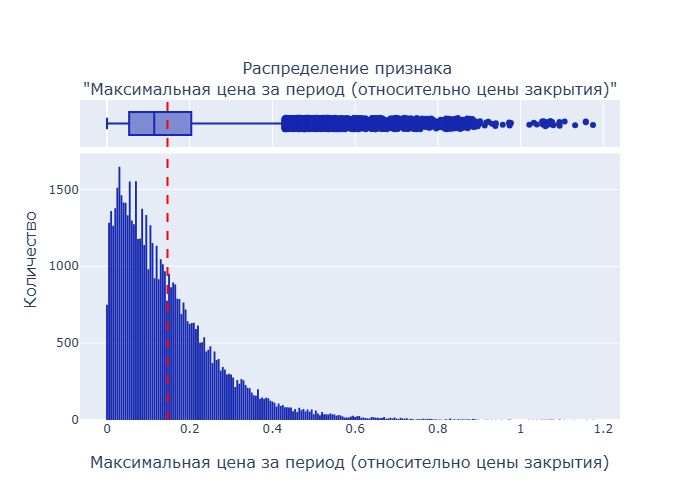

Статистические данные признака:


count    60844.00
mean         0.15
std          0.13
min          0.00
25%          0.05
50%          0.11
75%          0.20
max          1.18
Name: predict_high, dtype: float64

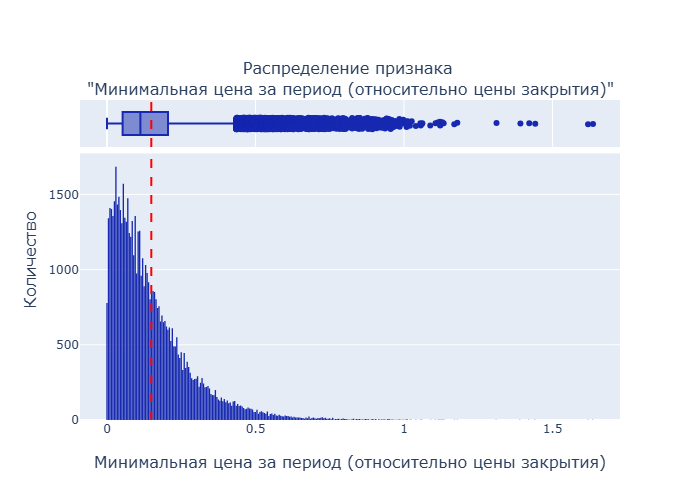

Статистические данные признака:


count    60844.00
mean         0.15
std          0.13
min         -0.00
25%          0.05
50%          0.11
75%          0.21
max          1.64
Name: predict_low, dtype: float64

In [107]:
# Преобразование целевых признаков
y_high_log = np.log1p(y_high)
y_low_log = np.log1p(-y_low) # с инверсией значений
# Построение гистограмм распределения целевых признаков
plot_numerical_feature(pd.DataFrame(y_high_log), 'predict_high', 'Максимальная цена за период (относительно цены закрытия)')
plot_numerical_feature(pd.DataFrame(y_low_log), 'predict_low', 'Минимальная цена за период (относительно цены закрытия)')

Преобразование сгладило экстремумы выборки для обучения.

В рамках торговой задачи логично рассматривать результаты работы моделей прогнозирования максимальной/минимальной цены актива за период как отправные точки для определения значений takeprofit и stoploss. Исходя из этого, в качестве основных метрик для определения качества моделей оптимально использовать:
- **MAE** — средняя абсолютная ошибка, для общего качества;
- **Asymmetric MAE** — основной показатель, где завышение (y_pred > y_true) штрафуется сильнее;
- **TP Hit Rate** — насколько часто фактический максимум достигает прогнозируемого TP.

In [108]:
def asymmetric_mae(y_true, y_pred, penalty=2):
    '''Ошибка с повышенным штрафом за завышение прогноза'''
    loss = np.where(y_pred > y_true,
                    penalty * np.abs(y_pred - y_true),
                    np.abs(y_pred - y_true))
    return loss.mean()


def metrics_print_rgr(model, X_tr, X_tst, y_tr, y_tst):
    '''Функция вывода оценок MAE, Asymmetric MAE и TP Hit Rate модели
    на тренировочных и тестовых данных '''
    y_pred_train = model.predict(X_tr)
    y_pred_test = model.predict(X_tst)
    # Возврат в исходный масштаб
    y_pred_train_exp = np.expm1(y_pred_train)
    y_pred_test_exp = np.expm1(y_pred_test)
    y_tr_exp = np.expm1(y_tr)
    y_tst_exp = np.expm1(y_tst)
    
    # Получение метрик модели
    # Asymmetric MAE
    loss_train = asymmetric_mae(y_tr_exp, y_pred_train_exp)
    loss_test = asymmetric_mae(y_tst_exp, y_pred_test_exp)
    # TP Hit Rate
    tp_hit_rate_train = np.mean(y_tr_exp >= y_pred_train_exp)
    tp_hit_rate_test = np.mean(y_tst_exp >= y_pred_test_exp)
    print('-------На тренировочных данных-------')
    print(f'MAE: {metrics.mean_absolute_error(y_tr_exp, y_pred_train_exp):.4f}    Asymmetric MAE: {loss_train:.4f}    TP Hit Rate: {tp_hit_rate_train:.4f}')
    print('-------На тестовых данных------------')
    print(f'MAE: {metrics.mean_absolute_error(y_tst_exp, y_pred_test_exp):.4f}    Asymmetric MAE: {loss_test:.4f}    TP Hit Rate: {tp_hit_rate_test:.4f}')

Проведена дополнительная обработка целевых признаков и уточнены метрики для определения качества моделей, приступаем к их формированию.

#### Прогнозирование максимальной цены
Обучение и оценка baseline-модели.

In [109]:
# Разбивка данных на тренировочную и тестовую выборки
X_train_high, X_test_high, y_train_high, y_test_high = train_test_split(X, y_high_log, test_size=0.2, shuffle=False, random_state=rs)
# Размерности выборок
print(f'Размерность обучающей выборки {X_train_high.shape}')
print(f'Размерность тестовой выборки {X_test_high.shape}')

Размерность обучающей выборки (48675, 163)
Размерность тестовой выборки (12169, 163)


In [110]:
# Создание модели случайного леса
model_high = RandomForestRegressor(n_estimators=100,    # 100 деревьев
                                   max_depth=10,        # ограничение глубины
                                   max_features='sqrt', # ограничение количества признаков, предотвращает переобучение
                                   min_samples_leaf=5,  # минимальное количество экземпляров в листе
                                   n_jobs=-1,
                                   random_state=rs)
# Обучение модели
model_high.fit(X_train_high, y_train_high)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [111]:
metrics_print_rgr(model_high, X_tr=X_train_high, X_tst=X_test_high, y_tr=y_train_high, y_tst=y_test_high)

-------На тренировочных данных-------
MAE: 0.0919    Asymmetric MAE: 0.1339    TP Hit Rate: 0.4087
-------На тестовых данных------------
MAE: 0.1345    Asymmetric MAE: 0.1780    TP Hit Rate: 0.4897


In [112]:
# Создание модели xgb
model_high = XGBRegressor(n_estimators=100, # 100 деревьев
                          max_depth=10,     # ограничение глубины
                          random_state=rs)
# Обучение модели
model_high.fit(X_train_high, y_train_high)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [113]:
metrics_print_rgr(model_high, X_tr=X_train_high, X_tst=X_test_high, y_tr=y_train_high, y_tst=y_test_high)

-------На тренировочных данных-------
MAE: 0.0107    Asymmetric MAE: 0.0157    TP Hit Rate: 0.4925
-------На тестовых данных------------
MAE: 0.1448    Asymmetric MAE: 0.2009    TP Hit Rate: 0.4721


Baseline-модели показывают достаточно высокие оценки на тренировочных данных, но низкие на тестовых, что показывает достаточно высокую степень переобученности полученных моделей, характерную для них.

#### Подбор гиперпараметров модели "Прогнозирование максимальной цены"

In [114]:
# Пространство поиска гиперпараметров
space_high = {'learning_rate': hp.choice('learning_rate', [0.01, 0.03, 0.05, 0.1]),
              'n_estimators': hp.choice('n_estimators', [100, 300, 500, 1000]),
              'max_depth': hp.choice('max_depth', [2, 3, 4, 5, 6, 7, 8]),
              'min_child_weight': hp.loguniform('min_child_weight', np.log(0.1), np.log(10)),
              'subsample': hp.uniform('subsample', 0.6, 1.0),
              'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
              'gamma': hp.loguniform('gamma', np.log(1e-8), np.log(5.0)),
              'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-8), np.log(10.0)),
              'reg_lambda': hp.loguniform('reg_lambda', np.log(1e-8), np.log(10.0)),
              'objective': 'reg:squarederror',
              'tree_method': 'hist',
              'eval_metric': 'rmse',
              'random_state': rs,
              'n_jobs': 4}

In [115]:
def hyperopt_high(params, cv=5, X=X_train_high, y=y_train_high):
    '''Функция подбора гиперпараметров модели прогнозирования максимально цены за период'''
    params["n_estimators"] = int(params["n_estimators"])
    params["max_depth"] = int(params["max_depth"])
    # Объявление модели
    model = XGBRegressor(**params)
    # Разбиение обучающей выборки
    cvs = TimeSeriesSplit(n_splits=cv)
    scores = []

    for train_idx, val_idx in cvs.split(X):
        X_train_cv = X.iloc[train_idx]
        X_val_cv = X.iloc[val_idx]
        y_train_cv = y.iloc[train_idx]
        y_val_cv = y.iloc[val_idx]
        model.fit(X_train_cv,
                  y_train_cv)
        y_pred = model.predict(X_val_cv)
        score = asymmetric_mae(y_val_cv.values,
                               y_pred,
                               penalty=2)
        scores.append(score)
        
    mean_score = np.mean(scores)
    # Возвращение результата
    return {'loss': mean_score,  # оценка
            'status': STATUS_OK, # статус обучения
            'params': params}    # параметры

In [116]:
# Подбор гиперпараметров
trials_high = Trials() # логирование результатов

if recalculating_model_high:
    best_high=fmin(hyperopt_high,      # функция 
                   space=space_high,   # пространство гиперпараметров
                   algo=tpe.suggest,   # алгоритм оптимизации
                   max_evals=50,      # максимальное количество итераций
                   trials=trials_high, # логирование результатов
                   rstate=np.random.default_rng(rs))

100%|██████████| 50/50 [08:39<00:00, 10.39s/trial, best loss: 0.12552030188357652]


In [117]:
# Вывод результатов подбора
if recalculating_model_high:
    best_trial_high = trials_high.best_trial
    params_high = best_trial_high['result']['params']
    print("\n=== Параметры ===")
    print(best_trial_high['result']['params'])
    print("\n=== Средний Asymmetric MAE ===")
    print(best_trial_high['result']['loss'])
else:
    params_high = {'colsample_bytree': 0.9271198027631056, 
                   'eval_metric': 'rmse', 
                   'gamma': 1.8360311346109488e-08, 
                   'learning_rate': 0.03, 
                   'max_depth': 2, 
                   'min_child_weight': 2.710122954291532, 
                   'n_estimators': 500, 
                   'n_jobs': 4, 
                   'objective': 'reg:squarederror', 
                   'random_state': 42, 
                   'reg_alpha': 0.019256423438228285, 
                   'reg_lambda': 1.1624679001533362e-06, 
                   'subsample': 0.6600813639272388, 
                   'tree_method': 'hist'}

    print('Параметры модели не пересчитывались\nСредний Asymmetric MAE 0.12552030188357652')
# Обучение итоговой модели
model_high_hyp_res = XGBRegressor(**params_high)
model_high_hyp_res.fit(X_train_high, y_train_high)


=== Параметры ===
{'colsample_bytree': 0.9271198027631056, 'eval_metric': 'rmse', 'gamma': 1.8360311346109488e-08, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 2.710122954291532, 'n_estimators': 500, 'n_jobs': 4, 'objective': 'reg:squarederror', 'random_state': 42, 'reg_alpha': 0.019256423438228285, 'reg_lambda': 1.1624679001533362e-06, 'subsample': 0.6600813639272388, 'tree_method': 'hist'}

=== Средний Asymmetric MAE ===
0.12552030188357652


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9271198027631056
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [118]:
metrics_print_rgr(model_high_hyp_res, X_tr=X_train_high, X_tst=X_test_high, y_tr=y_train_high, y_tst=y_test_high)

-------На тренировочных данных-------
MAE: 0.0961    Asymmetric MAE: 0.1404    TP Hit Rate: 0.4134
-------На тестовых данных------------
MAE: 0.1350    Asymmetric MAE: 0.1832    TP Hit Rate: 0.4765


In [119]:
print(np.expm1(y_test_high).mean())
print(np.expm1(model_high_hyp_res.predict(X_test_high)).mean())

0.21857087681814444
0.18011883


Исходя из полученных метрик, можно сделать вывод о низкой степени переобучения полученной модели и ее стабильность, средние значения тестового набора и прогнозов модели показывают, что модель стабильно занижает значения максимального движения, это характеризует ее как достаточно "осторожную" для определения takeprofit, что следует учитывать при построении торговой стратегии. Снижение данной "осторожности" может быть компенсировано применением коэффициента умножения прогноза.

#### Прогнозирование минимальной цены  

Обучение и оценка baseline-модели.

In [120]:
# Разбивка данных на тренировочную и тестовую выборки
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(X, y_low_log, test_size=0.2, shuffle=False, random_state=rs)
# Размерности выборок
print(f'Размерность обучающей выборки {X_train_low.shape}')
print(f'Размерность тестовой выборки {X_test_low.shape}')

Размерность обучающей выборки (48675, 163)
Размерность тестовой выборки (12169, 163)


In [121]:
# Создание модели случайного леса
model_low = RandomForestRegressor(n_estimators=100,    # 100 деревьев
                                  max_depth=10,        # ограничение глубины
                                  max_features='sqrt', # ограничение количества признаков, предотвращает переобучение
                                  min_samples_leaf=5,  # минимальное количество экземпляров в листе
                                  n_jobs=-1,
                                  random_state=rs)
# Обучение модели
model_low.fit(X_train_low, y_train_low)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [122]:
metrics_print_rgr(model_low, X_tr=X_train_low, X_tst=X_test_low, y_tr=y_train_low, y_tst=y_test_low)

-------На тренировочных данных-------
MAE: 0.0953    Asymmetric MAE: 0.1387    TP Hit Rate: 0.4027
-------На тестовых данных------------
MAE: 0.1536    Asymmetric MAE: 0.1953    TP Hit Rate: 0.5167


In [123]:
# Создание модели xgb
model_low = XGBRegressor(n_estimators=100, # 100 деревьев
                         max_depth=10,     # ограничение глубины
                         random_state=rs)
# Обучение модели
model_low.fit(X_train_low, y_train_low)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [124]:
metrics_print_rgr(model_low, X_tr=X_train_low, X_tst=X_test_low, y_tr=y_train_low, y_tst=y_test_low)

-------На тренировочных данных-------
MAE: 0.0108    Asymmetric MAE: 0.0158    TP Hit Rate: 0.4967
-------На тестовых данных------------
MAE: 0.1634    Asymmetric MAE: 0.2185    TP Hit Rate: 0.5109


Baseline-модели показывают достаточно высокие оценки на тренировочных данных, но низкие на тестовых, что показывает достаточно высокую степень переобученности полученных моделей, характерную для них.

#### Подбор гиперпараметров модели "Прогнозирование минимальной цены"

In [125]:
# Пространство поиска гиперпараметров
space_low = {'learning_rate': hp.choice('learning_rate', [0.01, 0.03, 0.05, 0.1]),
             'n_estimators': hp.choice('n_estimators', [100, 300, 500, 1000]),
             'max_depth': hp.choice('max_depth', [2, 3, 4, 5, 6, 7, 8]),
             'min_child_weight': hp.loguniform('min_child_weight', np.log(0.1), np.log(10)),
             'subsample': hp.uniform('subsample', 0.6, 1.0),
             'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
             'gamma': hp.loguniform('gamma', np.log(1e-8), np.log(5.0)),
             'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-8), np.log(10.0)),
             'reg_lambda': hp.loguniform('reg_lambda', np.log(1e-8), np.log(10.0)),
             'objective': 'reg:squarederror',
             'tree_method': 'hist',
             'eval_metric': 'rmse',
             'random_state': rs,
             'n_jobs': 4}

In [126]:
def hyperopt_low(params, cv=5, X=X_train_low, y=y_train_low):
    '''Функция подбора гиперпараметров модели прогнозирования минимальной цены за период'''
    params["n_estimators"] = int(params["n_estimators"])
    params["max_depth"] = int(params["max_depth"])
    # Объявление модели
    model = XGBRegressor(**params)
    # Разбиение обучающей выборки
    cvs = TimeSeriesSplit(n_splits=cv)
    scores = []

    for train_idx, val_idx in cvs.split(X):
        X_train_cv = X.iloc[train_idx]
        X_val_cv = X.iloc[val_idx]
        y_train_cv = y.iloc[train_idx]
        y_val_cv = y.iloc[val_idx]
        model.fit(X_train_cv,
                  y_train_cv)
        y_pred = model.predict(X_val_cv)
        score = asymmetric_mae(y_val_cv.values,
                               y_pred,
                               penalty=2)
        scores.append(score)
        
    mean_score = np.mean(scores)
    # Возвращение результата
    return {'loss': mean_score,  # оценка
            'status': STATUS_OK, # статус обучения
            'params': params}    # параметры

In [127]:
# Подбор гиперпараметров
trials_low = Trials() # логирование результатов

if recalculating_model_low:
    best_low=fmin(hyperopt_low,      # функция 
                  space=space_low,   # пространство гиперпараметров
                  algo=tpe.suggest,   # алгоритм оптимизации
                  max_evals=50,      # максимальное количество итераций
                  trials=trials_low, # логирование результатов
                  rstate=np.random.default_rng(rs))

100%|██████████| 50/50 [08:25<00:00, 10.11s/trial, best loss: 0.12955237014224258]


In [128]:
# Вывод результатов подбора
if recalculating_model_low:
    best_trial_low = trials_low.best_trial
    params_low = best_trial_low['result']['params']
    print("\n=== Параметры ===")
    print(best_trial_low['result']['params'])
    print("\n=== Средний Asymmetric MAE ===")
    print(best_trial_low['result']['loss'])
else:
    params_low = {'colsample_bytree': 0.8102773654663284, 
                  'eval_metric': 'rmse', 
                  'gamma': 0.5650419323394329, 
                  'learning_rate': 0.05, 
                  'max_depth': 3, 
                  'min_child_weight': 1.3978360543078747, 
                  'n_estimators': 500, 
                  'n_jobs': 4, 
                  'objective': 'reg:squarederror', 
                  'random_state': 42, 
                  'reg_alpha': 0.0036219934571295365, 
                  'reg_lambda': 4.602027706977151e-08, 
                  'subsample': 0.658785114914011, 
                  'tree_method': 'hist'}
    print('Параметры модели не пересчитывались\nСредний Asymmetric MAE 0.12955237014224258')
# Обучение итоговой модели
model_low_hyp_res = XGBRegressor(**params_low)
model_low_hyp_res.fit(X_train_low, y_train_low)


=== Параметры ===
{'colsample_bytree': 0.8102773654663284, 'eval_metric': 'rmse', 'gamma': 0.5650419323394329, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1.3978360543078747, 'n_estimators': 500, 'n_jobs': 4, 'objective': 'reg:squarederror', 'random_state': 42, 'reg_alpha': 0.0036219934571295365, 'reg_lambda': 4.602027706977151e-08, 'subsample': 0.658785114914011, 'tree_method': 'hist'}

=== Средний Asymmetric MAE ===
0.12955237014224258


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8102773654663284
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [129]:
metrics_print_rgr(model_low_hyp_res, X_tr=X_train_low, X_tst=X_test_low, y_tr=y_train_low, y_tst=y_test_low)

-------На тренировочных данных-------
MAE: 0.1008    Asymmetric MAE: 0.1471    TP Hit Rate: 0.4037
-------На тестовых данных------------
MAE: 0.1532    Asymmetric MAE: 0.1939    TP Hit Rate: 0.5298


In [130]:
print(np.expm1(y_test_low).mean())
print(np.expm1(model_low_hyp_res.predict(X_test_low)).mean())

0.24073958418933358
0.16906375


Исходя из полученных метрик, можно сделать вывод о низкой степени переобучения полученной модели и ее стабильность, средние значения тестового набора и прогнозов модели показывают, что модель стабильно занижает значения максимального движения, это характеризует ее как достаточно "осторожную" для определения takeprofit, что следует учитывать при построении торговой стратегии. Снижение данной "осторожности" может быть компенсировано применением коэффициента умножения прогноза.

> В ходе работы было сформировано четыре модели, позволяющих построить рекомендательную систему. Для ее построения необходимо учитывать особенности каждой модели.  
Для повышения качества прогнозов в дальнейшем можно использовать более глубокий анализ новостной ленты, провести выделение типовых отчетностей и показателей, фигурирующих в них, в отдельные признаки, добавить другие источники новостей/данных. Также, как вариант развития, для обучения моделей прогноза максимальной/минимальной цены за период можно рассмотреть вариант использования выборки данных, отмечаемых только в периоды направления движения цены актива вверх/вниз соответственно, можно добавить признак работы американской биржи/бирж других стран (True/False).  
Немаловажным этапом будет формирование торговой стратегии на базе сигналов, получаемых от моделей в комплексе, (в том числе и стратегии риск-менеджмента), и корректировка методик оценки сигналов моделей уже с точки зрения соотношения прибыль/убытки (лучше с учетом комиссионных платежей брокеру).  
Так как данный этап работы является стартовым и не предполагает решения поставленных вопросов, то переходим к финальному обучению моделей на полных данных, сохранению их в файлы и функций получения прогноза с учетом подготовки данных и их обработки (файл **getPredict.py**).

## Обучение моделей на полных данных и сохранение в файл

In [131]:
# Обучение моделей на полных данных
model_to_up_hyp_res.fit(X, y_to_up)
model_to_down_hyp_res.fit(X, y_to_down)
model_high_hyp_res.fit(X, y_high_log)
model_low_hyp_res.fit(X, y_low_log)

# Сохранение моделей в файл
joblib.dump(model_to_up_hyp_res, './models/model_to_up.pkl')
joblib.dump(model_to_down_hyp_res, './models/model_to_down.pkl')
joblib.dump(model_high_hyp_res, './models/model_high.pkl')
joblib.dump(model_low_hyp_res, './models/model_low.pkl')
# Сохранение кодировщиков
joblib.dump(encoder_day_of_week, './models/encoder_day_of_week.pkl')
joblib.dump(encoder_tags_comb, './models/encoder_tags_comb.pkl')
# Сохранение списка наиболее популярных сочетаний тегов
joblib.dump(top_tags_comb, './models/top_tags_comb.pkl')

['./models/top_tags_comb.pkl']